In [16]:
path = "/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/transfer/ladders/prodigy_nm/robustness/nm_ladder_order_robustness/data/nm_ladder_order_robustness.csv"

In [17]:
import pandas as pd

In [18]:
df = pd.read_csv(path)

In [23]:
df.sample(3).to_clipboard()

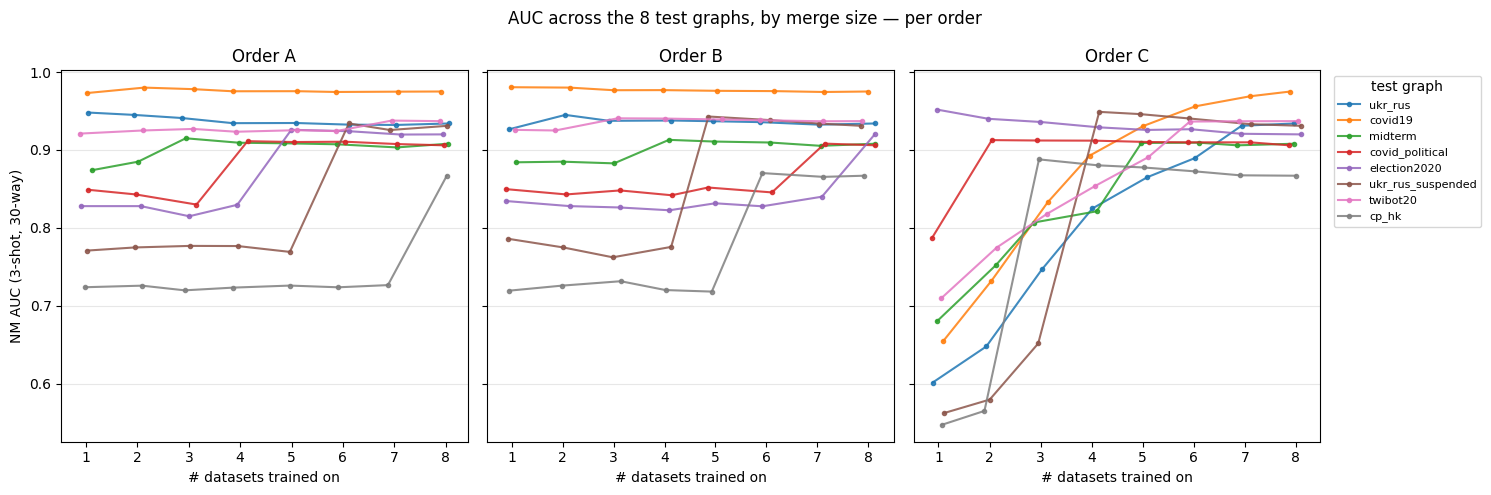

In [41]:
import numpy as np
import matplotlib.pyplot as plt

META = ["order", "rung", "n_sources", "added", "sources", "status", "provenance"]
test_cols = [c for c in df.columns if c not in META]
orders = ["A", "B", "C"]

cmap = plt.get_cmap("tab10")
colors = {c: cmap(i) for i, c in enumerate(test_cols)}
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, len(orders), figsize=(5 * len(orders), 5), sharey=True)

for ax, o in zip(axes, orders):
    sub = df[df["order"] == o].sort_values("n_sources")
    for c in test_cols:
        x = sub["n_sources"].astype(float).values + rng.uniform(-0.15, 0.15, len(sub))
        ax.plot(x, sub[c].astype(float).values,
                color=colors[c],
                # s=45,
                   alpha=0.85,
                #    edgecolor="white",
                #    linewidth=0,
                   marker='.',
                   label=c.replace("_twitter", ""))
    ax.set_title(f"Order {o}")
    ax.set_xlabel("# datasets trained on")
    ax.set_xticks(range(1, 9))
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("NM AUC (3-shot, 30-way)")
axes[-1].legend(title="test graph", fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("AUC across the 8 test graphs, by merge size — per order")
fig.tight_layout()
plt.show()

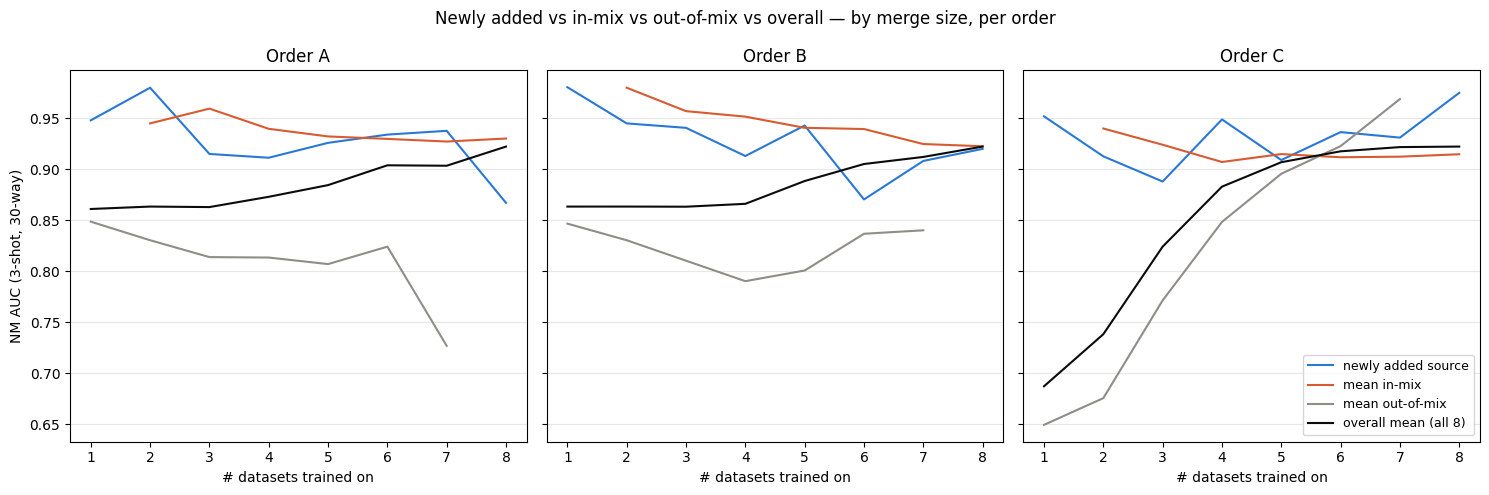

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

META = ["order", "rung", "n_sources", "added", "sources", "status", "provenance"]
test_cols = [c for c in df.columns if c not in META]
orders = ["A", "B", "C"]

KEY2COL = {
    "ukr_rus": "ukr_rus_twitter", "covid": "covid19_twitter", "midterm": "midterm",
    "covid_political": "covid_political", "election2020": "election2020",
    "ukr_rus_suspended": "ukr_rus_suspended", "twibot20": "twibot20",
    "cp_hk": "cp_hk_twitter",
}
C_NEW, C_IN, C_OUT, C_ALL = "#2a78d6", "#d85a30", "#8f8d87", "#0b0b0b"

fig, axes = plt.subplots(1, len(orders), figsize=(5 * len(orders), 5), sharey=True)

for ax, o in zip(axes, orders):
    sub = df[df["order"] == o].sort_values("n_sources")
    xs, newc, inmix, outmix, allmean = [], [], [], [], []
    for _, row in sub.iterrows():
        in_cols = [KEY2COL[k] for k in row["sources"].split()]
        new_col = KEY2COL[row["added"]]
        incum = [c for c in in_cols if c != new_col]
        out = [c for c in test_cols if c not in in_cols]
        xs.append(row["n_sources"])
        newc.append(float(row[new_col]))
        inmix.append(np.mean([float(row[c]) for c in incum]) if incum else np.nan)
        outmix.append(np.mean([float(row[c]) for c in out]) if out else np.nan)
        allmean.append(np.mean([float(row[c]) for c in test_cols]))   # overall mean
    ax.plot(xs, newc,    color=C_NEW,  label="newly added source", zorder=3)
    ax.plot(xs, inmix,   color=C_IN,   label="mean in-mix", zorder=3)
    ax.plot(xs, outmix,  color=C_OUT,  label="mean out-of-mix", zorder=3)
    ax.plot(xs, allmean, color=C_ALL,  label="overall mean (all 8)", zorder=3)
    ax.set_title(f"Order {o}")
    ax.set_xlabel("# datasets trained on")
    ax.set_xticks(range(1, 9))
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("NM AUC (3-shot, 30-way)")
axes[-1].legend(fontsize=9, loc="lower right")
fig.suptitle("Newly added vs in-mix vs out-of-mix vs overall — by merge size, per order")   
fig.tight_layout()
plt.show()

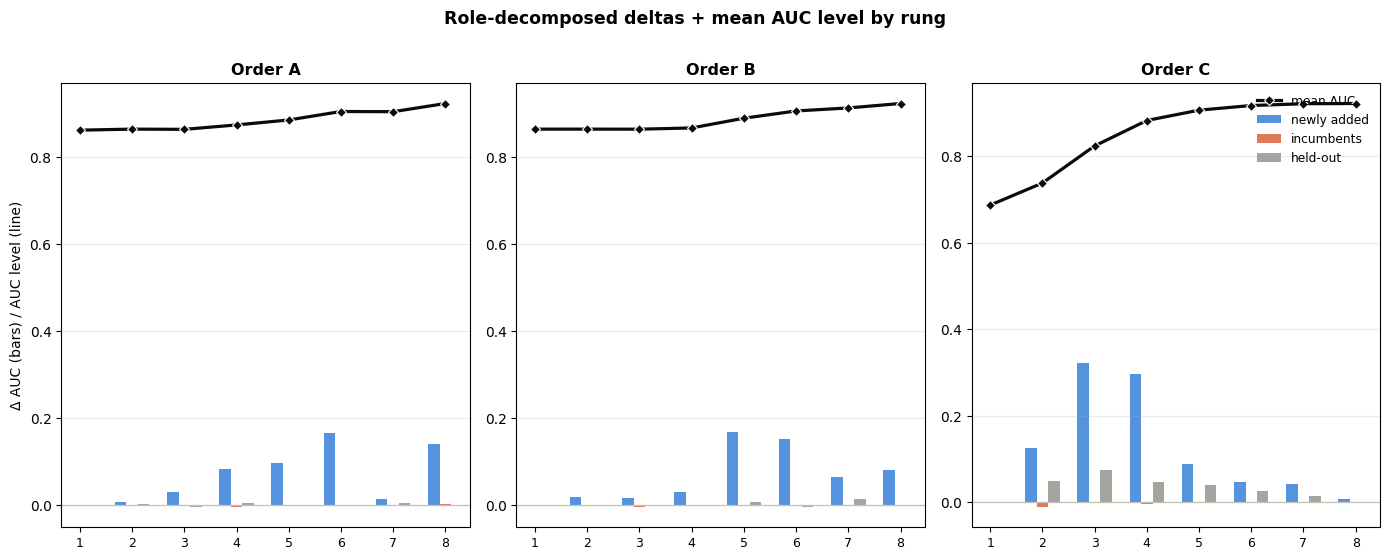

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=False)

for ax, o in zip(axes, ['A', 'B', 'C']):
    sub = df[df['order'] == o].reset_index(drop=True)
    xs, newc, incu, held, allmean = [], [], [], [], []
    
    # Rung 1: no deltas, just mean AUC
    row_r1 = sub.iloc[0]
    xs.append(row_r1['rung'])
    newc.append(np.nan)
    incu.append(np.nan)
    held.append(np.nan)
    allmean.append(row_r1[test_cols].astype(float).mean())
    
    # Rungs 2-8: deltas + mean AUC
    for i in range(1, len(sub)):
        row_prev = sub.iloc[i-1]
        row_curr = sub.iloc[i]
        
        deltas = row_curr[test_cols].astype(float) - row_prev[test_cols].astype(float)
        
        in_cols = [KEY2COL[k] for k in row_curr['sources'].split()]
        new_col = KEY2COL[row_curr['added']]
        incum = [c for c in in_cols if c != new_col]
        out_cols = [g for g in test_cols if g not in in_cols]
        
        newc_val = deltas[new_col]
        incu_vals = [deltas[c] for c in incum]
        held_vals = [deltas[c] for c in out_cols]
        
        xs.append(row_curr['rung'])
        newc.append(newc_val)
        incu.append(np.mean(incu_vals) if incu_vals else np.nan)
        held.append(np.mean(held_vals) if held_vals else np.nan)
        allmean.append(row_curr[test_cols].astype(float).mean())
    
    x = np.arange(len(xs))
    w = 0.22
    ax.bar(x - w, newc, width=w, color='#2a78d6', label='newly added', alpha=0.8)
    ax.bar(x, incu, width=w, color='#d85a30', label='incumbents', alpha=0.8)
    ax.bar(x + w, held, width=w, color='#8f8d87', label='held-out', alpha=0.8)
    ax.plot(x, allmean, color='#0b0b0b', lw=2.3, marker='D', ms=5.5,
            markeredgecolor='white', markeredgewidth=0.8, label='mean AUC', zorder=5)
    ax.axhline(0, color='#c3c2b7', lw=0.9, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(r)) for r in xs], fontsize=9)
    ax.set_title(f'Order {o}', fontsize=11.5, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, zorder=0)

axes[0].set_ylabel('Δ AUC (bars) / AUC level (line)', fontsize=10)
axes[-1].legend(loc='upper right', fontsize=8.8, frameon=False)
fig.suptitle('Role-decomposed deltas + mean AUC level by rung',
             fontsize=12.5, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

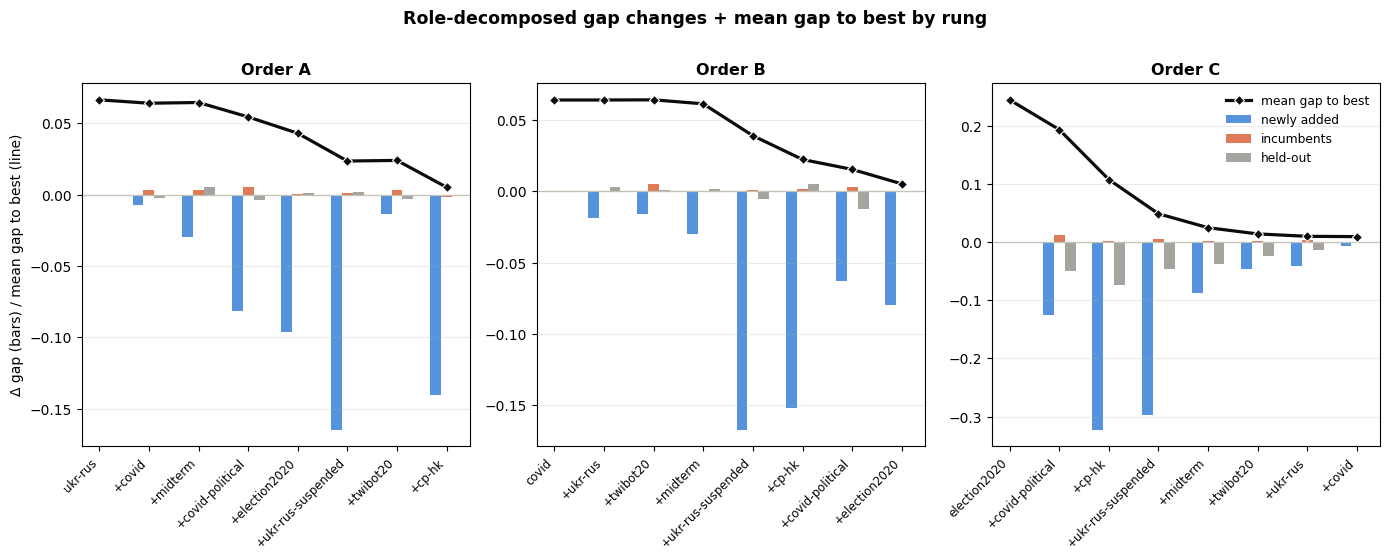

In [58]:
import numpy as np
import matplotlib.pyplot as plt

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

# Compute best AUC (at entry) for each (order, graph) pair
best_auc = {}
for o in ['A', 'B', 'C']:
    sub = df[df['order'] == o].reset_index(drop=True)
    for g in test_cols:
        for _, row in sub.iterrows():
            sources_list = [KEY2COL[k] for k in row['sources'].split()]
            if g in sources_list:
                best_auc[(o, g)] = float(row[g])
                break

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=False)

for ax, o in zip(axes, ['A', 'B', 'C']):
    sub = df[df['order'] == o].reset_index(drop=True)
    xs, labels, newc, incu, held, allmean = [], [], [], [], [], []
    
    # Rung 1
    row_r1 = sub.iloc[0]
    xs.append(row_r1['rung'])
    labels.append(row_r1['added'].replace('_', '-'))
    newc.append(np.nan)
    incu.append(np.nan)
    held.append(np.nan)
    gap_r1 = np.mean([best_auc[(o, g)] - float(row_r1[g]) for g in test_cols])
    allmean.append(gap_r1)
    
    # Rungs 2-8
    for i in range(1, len(sub)):
        row_prev = sub.iloc[i-1]
        row_curr = sub.iloc[i]
        
        gaps_prev = {g: best_auc[(o, g)] - float(row_prev[g]) for g in test_cols}
        gaps_curr = {g: best_auc[(o, g)] - float(row_curr[g]) for g in test_cols}
        deltas = {g: gaps_curr[g] - gaps_prev[g] for g in test_cols}
        
        in_cols = [KEY2COL[k] for k in row_curr['sources'].split()]
        new_col = KEY2COL[row_curr['added']]
        incum = [c for c in in_cols if c != new_col]
        out_cols = [g for g in test_cols if g not in in_cols]
        
        newc_val = deltas[new_col]
        incu_vals = [deltas[c] for c in incum]
        held_vals = [deltas[c] for c in out_cols]
        
        xs.append(row_curr['rung'])
        labels.append('+' + row_curr['added'].replace('_', '-'))
        newc.append(newc_val)
        incu.append(np.mean(incu_vals) if incu_vals else np.nan)
        held.append(np.mean(held_vals) if held_vals else np.nan)
        mean_gap = np.mean([gaps_curr[g] for g in test_cols])
        allmean.append(mean_gap)
    
    x = np.arange(len(xs))
    w = 0.22
    ax.bar(x - w, newc, width=w, color='#2a78d6', label='newly added', alpha=0.8)
    ax.bar(x, incu, width=w, color='#d85a30', label='incumbents', alpha=0.8)
    ax.bar(x + w, held, width=w, color='#8f8d87', label='held-out', alpha=0.8)
    ax.plot(x, allmean, color='#0b0b0b', lw=2.3, marker='D', ms=5.5,
            markeredgecolor='white', markeredgewidth=0.8, label='mean gap to best', zorder=5)
    ax.axhline(0, color='#c3c2b7', lw=0.9, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8.5, rotation=45, ha='right')
    ax.set_title(f'Order {o}', fontsize=11.5, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, zorder=0)

axes[0].set_ylabel('Δ gap (bars) / mean gap to best (line)', fontsize=10)
axes[-1].legend(loc='upper right', fontsize=8.8, frameon=False)
fig.suptitle('Role-decomposed gap changes + mean gap to best by rung',
             fontsize=12.5, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

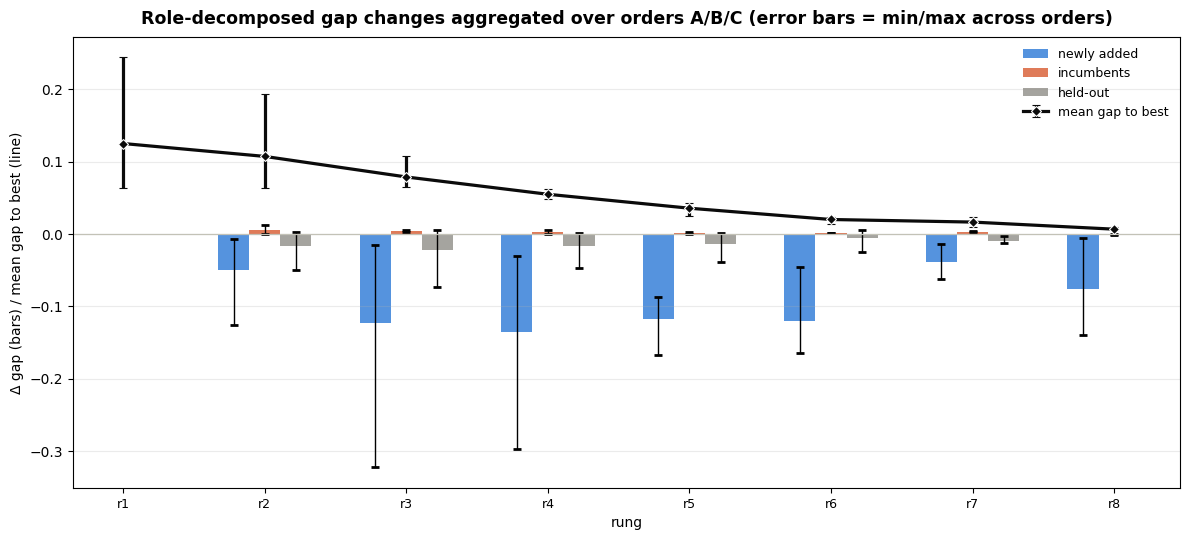

In [67]:
import numpy as np
import matplotlib.pyplot as plt

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

# Compute best AUC (at entry) for each (order, graph) pair
best_auc = {}
for o in ['A', 'B', 'C']:
    sub = df[df['order'] == o].reset_index(drop=True)
    for g in test_cols:
        for _, row in sub.iterrows():
            sources_list = [KEY2COL[k] for k in row['sources'].split()]
            if g in sources_list:
                best_auc[(o, g)] = float(row[g])
                break

# Aggregate across orders
by_rung = {r: {'newc': [], 'incu': [], 'held': [], 'gap': []} for r in range(1, 9)}

for o in ['A', 'B', 'C']:
    sub = df[df['order'] == o].reset_index(drop=True)
    
    # Rung 1
    row_r1 = sub.iloc[0]
    gap_r1 = np.mean([best_auc[(o, g)] - float(row_r1[g]) for g in test_cols])
    by_rung[1]['gap'].append(gap_r1)
    
    # Rungs 2-8
    for i in range(1, len(sub)):
        row_prev = sub.iloc[i-1]
        row_curr = sub.iloc[i]
        rr = int(row_curr['rung'])
        
        gaps_prev = {g: best_auc[(o, g)] - float(row_prev[g]) for g in test_cols}
        gaps_curr = {g: best_auc[(o, g)] - float(row_curr[g]) for g in test_cols}
        deltas = {g: gaps_curr[g] - gaps_prev[g] for g in test_cols}
        
        in_cols = [KEY2COL[k] for k in row_curr['sources'].split()]
        new_col = KEY2COL[row_curr['added']]
        incum = [c for c in in_cols if c != new_col]
        out_cols = [g for g in test_cols if g not in in_cols]
        
        newc_val = deltas[new_col]
        incu_vals = [deltas[c] for c in incum]
        held_vals = [deltas[c] for c in out_cols]
        mean_gap = np.mean([gaps_curr[g] for g in test_cols])
        
        by_rung[rr]['newc'].append(newc_val)
        by_rung[rr]['incu'].append(np.mean(incu_vals) if incu_vals else np.nan)
        by_rung[rr]['held'].append(np.mean(held_vals) if held_vals else np.nan)
        by_rung[rr]['gap'].append(mean_gap)

# Compute means and min/max error bars
xs, labels = list(range(1, 9)), []
newc_mu, incu_mu, held_mu, gap_mu = [], [], [], []
newc_err, incu_err, held_err, gap_err = [], [], [], []

for r in range(1, 9):
    # Newcomer
    if by_rung[r]['newc']:
        m = np.nanmean(by_rung[r]['newc'])
        newc_mu.append(m)
        newc_err.append([m - np.nanmin(by_rung[r]['newc']), 
                         np.nanmax(by_rung[r]['newc']) - m])
    else:
        newc_mu.append(np.nan)
        newc_err.append([0, 0])
    
    # Incumbent
    if by_rung[r]['incu']:
        m = np.nanmean(by_rung[r]['incu'])
        incu_mu.append(m)
        incu_err.append([m - np.nanmin(by_rung[r]['incu']), 
                         np.nanmax(by_rung[r]['incu']) - m])
    else:
        incu_mu.append(np.nan)
        incu_err.append([0, 0])
    
    # Held-out (may be empty at rung 8)
    held_vals = [v for v in by_rung[r]['held'] if not np.isnan(v)]
    if held_vals:
        m = np.nanmean(by_rung[r]['held'])
        held_mu.append(m)
        held_err.append([m - np.nanmin(by_rung[r]['held']), 
                         np.nanmax(by_rung[r]['held']) - m])
    else:
        held_mu.append(np.nan)
        held_err.append([0, 0])
    
    # Gap
    m = np.nanmean(by_rung[r]['gap'])
    gap_mu.append(m)
    gap_err.append([m - np.nanmin(by_rung[r]['gap']), 
                    np.nanmax(by_rung[r]['gap']) - m])
    
    labels.append(f"r{r}")

# Convert error lists to arrays for matplotlib
newc_err = np.array(newc_err).T
incu_err = np.array(incu_err).T
held_err = np.array(held_err).T
gap_err = np.array(gap_err).T

x = np.arange(len(xs))
w = 0.22

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(x - w, newc_mu, width=w, color='#2a78d6', label='newly added', alpha=0.8,
       yerr=newc_err, capsize=3, error_kw={'elinewidth': 1, 'capthick': 2})
ax.bar(x, incu_mu, width=w, color='#d85a30', label='incumbents', alpha=0.8,
       yerr=incu_err, capsize=3, error_kw={'elinewidth': 1, 'capthick': 2})
ax.bar(x + w, held_mu, width=w, color='#8f8d87', label='held-out', alpha=0.8,
       yerr=held_err, capsize=3, error_kw={'elinewidth': 1, 'capthick': 2})
ax.errorbar(x, gap_mu, yerr=gap_err, color='#0b0b0b', lw=2.3, ms=5.5,
            markeredgecolor='white', markeredgewidth=0.8, label='mean gap to best', 
            capsize=3, zorder=5, fmt='D-')

ax.axhline(0, color='#c3c2b7', lw=0.9, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_xlabel('rung', fontsize=10)
ax.set_ylabel('Δ gap (bars) / mean gap to best (line)', fontsize=10)
ax.grid(axis='y', alpha=0.25, zorder=0)
ax.legend(loc='upper right', fontsize=9, frameon=False)
ax.set_title('Role-decomposed gap changes aggregated over orders A/B/C (error bars = min/max across orders)',
             fontsize=12.5, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

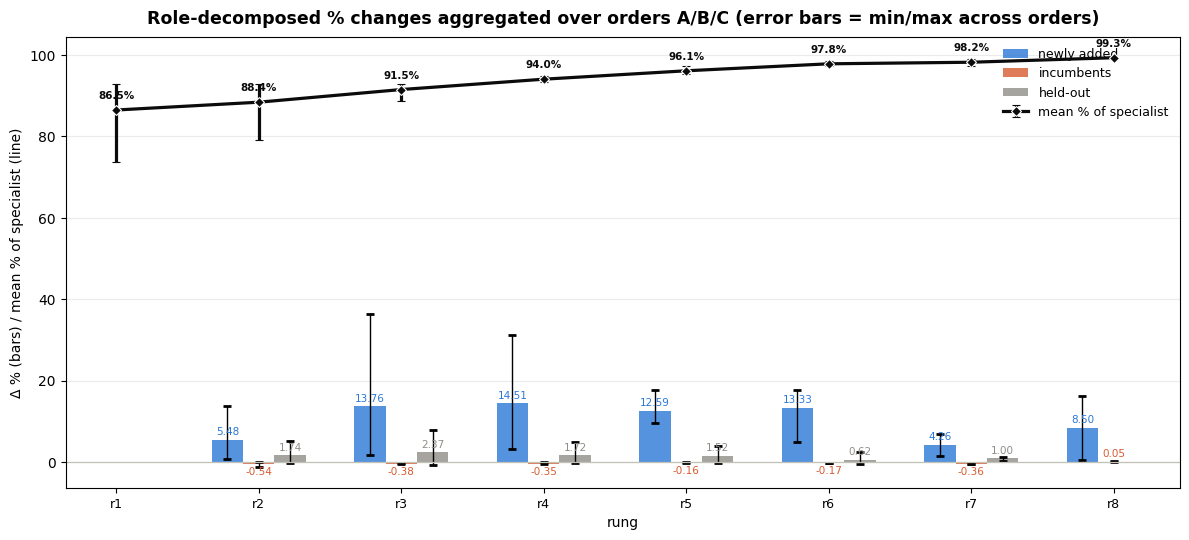

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

# Compute best AUC (at entry) for each (order, graph) pair
best_auc = {}
for o in ['A', 'B', 'C']:
    sub = df[df['order'] == o].reset_index(drop=True)
    for g in test_cols:
        for _, row in sub.iterrows():
            sources_list = [KEY2COL[k] for k in row['sources'].split()]
            if g in sources_list:
                best_auc[(o, g)] = float(row[g])
                break

# Aggregate across orders
by_rung = {r: {'newc': [], 'incu': [], 'held': [], 'pct': []} for r in range(1, 9)}

for o in ['A', 'B', 'C']:
    sub = df[df['order'] == o].reset_index(drop=True)
    
    # Rung 1
    row_r1 = sub.iloc[0]
    pct_r1 = np.mean([float(row_r1[g]) / best_auc[(o, g)] * 100 for g in test_cols])
    by_rung[1]['pct'].append(pct_r1)
    
    # Rungs 2-8
    for i in range(1, len(sub)):
        row_prev = sub.iloc[i-1]
        row_curr = sub.iloc[i]
        rr = int(row_curr['rung'])
        
        pcts_prev = {g: float(row_prev[g]) / best_auc[(o, g)] * 100 for g in test_cols}
        pcts_curr = {g: float(row_curr[g]) / best_auc[(o, g)] * 100 for g in test_cols}
        deltas = {g: pcts_curr[g] - pcts_prev[g] for g in test_cols}
        
        in_cols = [KEY2COL[k] for k in row_curr['sources'].split()]
        new_col = KEY2COL[row_curr['added']]
        incum = [c for c in in_cols if c != new_col]
        out_cols = [g for g in test_cols if g not in in_cols]
        
        newc_val = deltas[new_col]
        incu_vals = [deltas[c] for c in incum]
        held_vals = [deltas[c] for c in out_cols]
        mean_pct = np.mean([pcts_curr[g] for g in test_cols])
        
        by_rung[rr]['newc'].append(newc_val)
        by_rung[rr]['incu'].append(np.mean(incu_vals) if incu_vals else np.nan)
        by_rung[rr]['held'].append(np.mean(held_vals) if held_vals else np.nan)
        by_rung[rr]['pct'].append(mean_pct)

# Compute means and min/max error bars
xs, labels = list(range(1, 9)), []
newc_mu, incu_mu, held_mu, pct_mu = [], [], [], []
newc_err, incu_err, held_err, pct_err = [], [], [], []

for r in range(1, 9):
    if by_rung[r]['newc']:
        m = np.nanmean(by_rung[r]['newc'])
        newc_mu.append(m)
        newc_err.append([m - np.nanmin(by_rung[r]['newc']), 
                         np.nanmax(by_rung[r]['newc']) - m])
    else:
        newc_mu.append(np.nan)
        newc_err.append([0, 0])
    
    if by_rung[r]['incu']:
        m = np.nanmean(by_rung[r]['incu'])
        incu_mu.append(m)
        incu_err.append([m - np.nanmin(by_rung[r]['incu']), 
                         np.nanmax(by_rung[r]['incu']) - m])
    else:
        incu_mu.append(np.nan)
        incu_err.append([0, 0])
    
    held_vals = [v for v in by_rung[r]['held'] if not np.isnan(v)]
    if held_vals:
        m = np.nanmean(by_rung[r]['held'])
        held_mu.append(m)
        held_err.append([m - np.nanmin(by_rung[r]['held']), 
                         np.nanmax(by_rung[r]['held']) - m])
    else:
        held_mu.append(np.nan)
        held_err.append([0, 0])
    
    m = np.nanmean(by_rung[r]['pct'])
    pct_mu.append(m)
    pct_err.append([m - np.nanmin(by_rung[r]['pct']), 
                    np.nanmax(by_rung[r]['pct']) - m])
    
    labels.append(f"r{r}")

newc_err = np.array(newc_err).T
incu_err = np.array(incu_err).T
held_err = np.array(held_err).T
pct_err = np.array(pct_err).T

x = np.arange(len(xs))
w = 0.22

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(x - w, newc_mu, width=w, color='#2a78d6', label='newly added', alpha=0.8,
       yerr=newc_err, capsize=3, error_kw={'elinewidth': 1, 'capthick': 2})
ax.bar(x, incu_mu, width=w, color='#d85a30', label='incumbents', alpha=0.8,
       yerr=incu_err, capsize=3, error_kw={'elinewidth': 1, 'capthick': 2})
ax.bar(x + w, held_mu, width=w, color='#8f8d87', label='held-out', alpha=0.8,
       yerr=held_err, capsize=3, error_kw={'elinewidth': 1, 'capthick': 2})
ax.errorbar(x, pct_mu, yerr=pct_err, color='#0b0b0b', lw=2.3, ms=5.5,
            markeredgecolor='white', markeredgewidth=0.8, label='mean % of specialist', 
            capsize=3, zorder=5, fmt='D-')

# Annotate bars
for i, (nc, ic, hc) in enumerate(zip(newc_mu, incu_mu, held_mu)):
    if not np.isnan(nc):
        va = 'bottom' if nc >= 0 else 'top'
        ofs = 2 if nc >= 0 else -2
        ax.annotate(f'{nc:.2f}', xy=(x[i] - w, nc), xytext=(0, ofs),
                    textcoords='offset points', ha='center', va=va, fontsize=7.5, color='#2a78d6')
    if not np.isnan(ic):
        va = 'bottom' if ic >= 0 else 'top'
        ofs = 2 if ic >= 0 else -2
        ax.annotate(f'{ic:.2f}', xy=(x[i], ic), xytext=(0, ofs),
                    textcoords='offset points', ha='center', va=va, fontsize=7.5, color='#d85a30')
    if not np.isnan(hc):
        va = 'bottom' if hc >= 0 else 'top'
        ofs = 2 if hc >= 0 else -2
        ax.annotate(f'{hc:.2f}', xy=(x[i] + w, hc), xytext=(0, ofs),
                    textcoords='offset points', ha='center', va=va, fontsize=7.5, color='#8f8d87')

# Annotate line
for i, pct in enumerate(pct_mu):
    ax.annotate(f'{pct:.1f}%', xy=(x[i], pct), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=7.5, color='#0b0b0b', fontweight='bold')

ax.axhline(0, color='#c3c2b7', lw=0.9, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_xlabel('rung', fontsize=10)
ax.set_ylabel('Δ % (bars) / mean % of specialist (line)', fontsize=10)
ax.grid(axis='y', alpha=0.25, zorder=0)
ax.legend(loc='upper right', fontsize=9, frameon=False)
ax.set_title('Role-decomposed % changes aggregated over orders A/B/C (error bars = min/max across orders)',
             fontsize=12.5, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

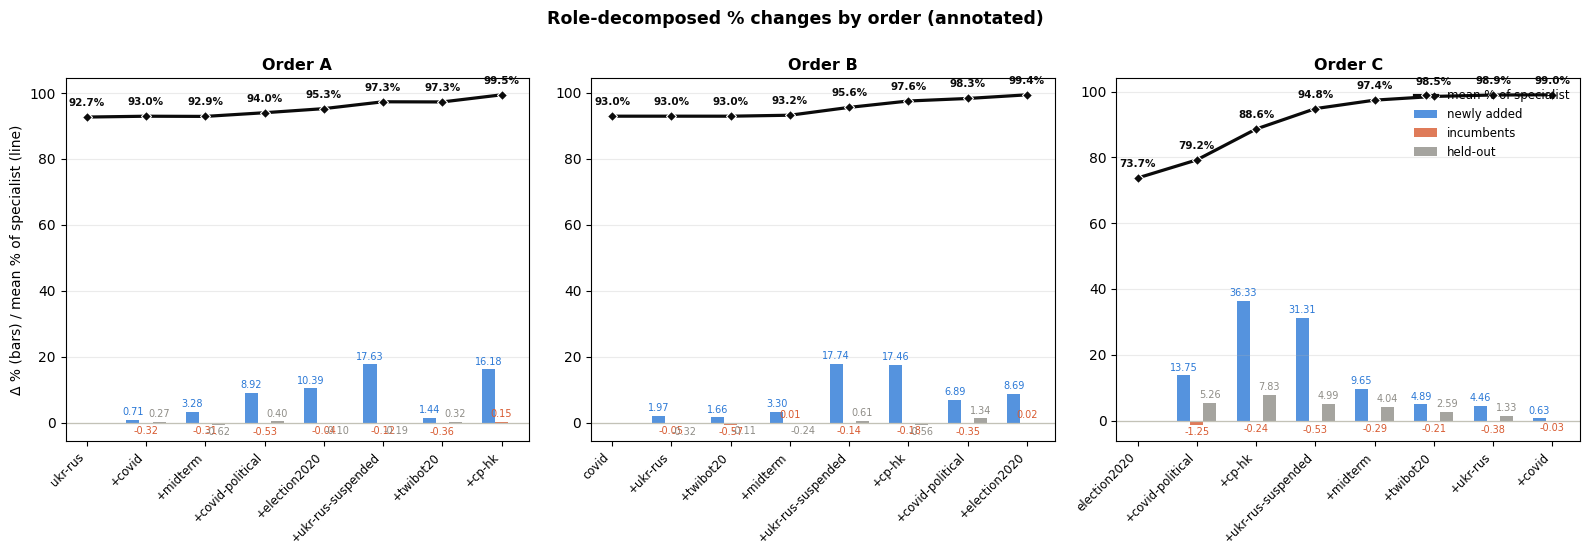

In [71]:
import numpy as np
import matplotlib.pyplot as plt

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

# Compute best AUC (at entry) for each (order, graph) pair
best_auc = {}
for o in ['A', 'B', 'C']:
    sub = df[df['order'] == o].reset_index(drop=True)
    for g in test_cols:
        for _, row in sub.iterrows():
            sources_list = [KEY2COL[k] for k in row['sources'].split()]
            if g in sources_list:
                best_auc[(o, g)] = float(row[g])
                break

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=False)

for ax, o in zip(axes, ['A', 'B', 'C']):
    sub = df[df['order'] == o].reset_index(drop=True)
    xs, labels, newc_mu, incu_mu, held_mu, pct_mu = [], [], [], [], [], []
    
    # Rung 1
    row_r1 = sub.iloc[0]
    xs.append(1)
    labels.append(row_r1['added'].replace('_', '-'))
    newc_mu.append(np.nan)
    incu_mu.append(np.nan)
    held_mu.append(np.nan)
    pct_r1 = np.mean([float(row_r1[g]) / best_auc[(o, g)] * 100 for g in test_cols])
    pct_mu.append(pct_r1)
    
    # Rungs 2-8
    for i in range(1, len(sub)):
        row_prev = sub.iloc[i-1]
        row_curr = sub.iloc[i]
        rr = int(row_curr['rung'])
        
        pcts_prev = {g: float(row_prev[g]) / best_auc[(o, g)] * 100 for g in test_cols}
        pcts_curr = {g: float(row_curr[g]) / best_auc[(o, g)] * 100 for g in test_cols}
        deltas = {g: pcts_curr[g] - pcts_prev[g] for g in test_cols}
        
        in_cols = [KEY2COL[k] for k in row_curr['sources'].split()]
        new_col = KEY2COL[row_curr['added']]
        incum = [c for c in in_cols if c != new_col]
        out_cols = [g for g in test_cols if g not in in_cols]
        
        newc_val = deltas[new_col]
        incu_vals = [deltas[c] for c in incum]
        held_vals = [deltas[c] for c in out_cols]
        mean_pct = np.mean([pcts_curr[g] for g in test_cols])
        
        xs.append(rr)
        labels.append('+' + row_curr['added'].replace('_', '-'))
        newc_mu.append(newc_val)
        incu_mu.append(np.mean(incu_vals) if incu_vals else np.nan)
        held_mu.append(np.mean(held_vals) if held_vals else np.nan)
        pct_mu.append(mean_pct)
    
    x = np.arange(len(xs))
    w = 0.22
    
    ax.bar(x - w, newc_mu, width=w, color='#2a78d6', label='newly added', alpha=0.8)
    ax.bar(x, incu_mu, width=w, color='#d85a30', label='incumbents', alpha=0.8)
    ax.bar(x + w, held_mu, width=w, color='#8f8d87', label='held-out', alpha=0.8)
    ax.plot(x, pct_mu, color='#0b0b0b', lw=2.3, marker='D', ms=5.5,
            markeredgecolor='white', markeredgewidth=0.8, label='mean % of specialist', zorder=5)
    
    # Annotate bars
    for i, (nc, ic, hc) in enumerate(zip(newc_mu, incu_mu, held_mu)):
        if not np.isnan(nc):
            va = 'bottom' if nc >= 0 else 'top'
            ofs = 2 if nc >= 0 else -2
            ax.annotate(f'{nc:.2f}', xy=(x[i] - w, nc), xytext=(0, ofs),
                        textcoords='offset points', ha='center', va=va, fontsize=7, color='#2a78d6')
        if not np.isnan(ic):
            va = 'bottom' if ic >= 0 else 'top'
            ofs = 2 if ic >= 0 else -2
            ax.annotate(f'{ic:.2f}', xy=(x[i], ic), xytext=(0, ofs),
                        textcoords='offset points', ha='center', va=va, fontsize=7, color='#d85a30')
        if not np.isnan(hc):
            va = 'bottom' if hc >= 0 else 'top'
            ofs = 2 if hc >= 0 else -2
            ax.annotate(f'{hc:.2f}', xy=(x[i] + w, hc), xytext=(0, ofs),
                        textcoords='offset points', ha='center', va=va, fontsize=7, color='#8f8d87')
    
    # Annotate line
    for i, pct in enumerate(pct_mu):
        ax.annotate(f'{pct:.1f}%', xy=(x[i], pct), xytext=(0, 8),
                    textcoords='offset points', ha='center', fontsize=7.5, color='#0b0b0b', fontweight='bold')
    
    ax.axhline(0, color='#c3c2b7', lw=0.9, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8.5, rotation=45, ha='right')
    ax.set_title(f'Order {o}', fontsize=11.5, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, zorder=0)

axes[0].set_ylabel('Δ % (bars) / mean % of specialist (line)', fontsize=10)
axes[-1].legend(loc='upper right', fontsize=8.5, frameon=False)
fig.suptitle('Role-decomposed % changes by order (annotated)',
             fontsize=12.5, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()

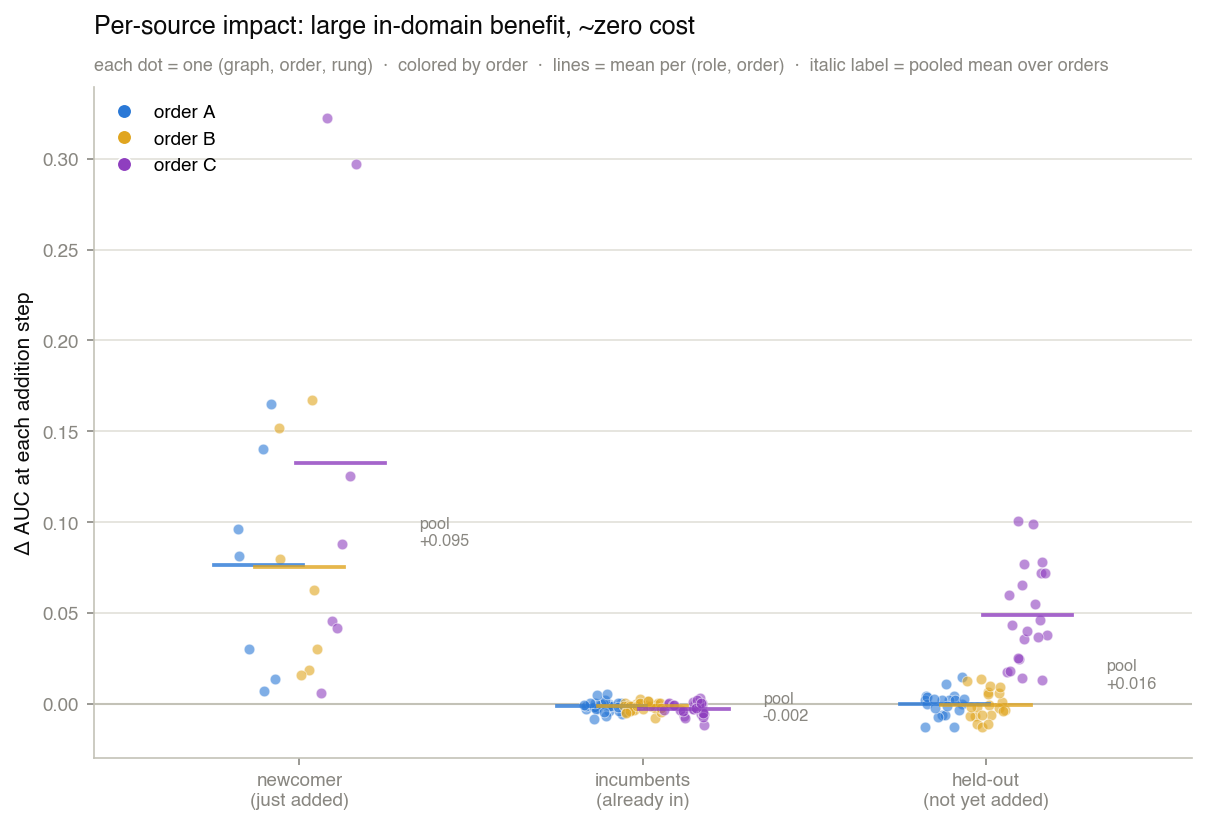


role            n     mean      min      max
  newcomer      21  +0.0945  +0.0061  +0.3226
  incumbents    84  -0.0019  -0.0119  +0.0054
  held-out      63  +0.0161  -0.0130  +0.1006

order  newcomer      incumbent      held-out
  A     +0.0761        -0.0015       -0.0001
  B     +0.0752        -0.0015       -0.0006
  C     +0.1323        -0.0027       +0.0491


In [111]:
#!/usr/bin/env python3
"""Order-robustness figures from wide-format DataFrame."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.lines import Line2D

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

BLUE = "#2a78d6"
CORAL = "#d85a30"
GRAY = "#8f8d87"
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
ORDER_C = {"A": "#2a78d6", "B": "#e0a51f", "C": "#8f3fbf"}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})


def chrome(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c3c2b7")
    ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)


"""Per-source impact by role, colored by order."""
# Collect data by (order, role)
data = defaultdict(lambda: defaultdict(list))  # order -> role -> list of deltas

for order in df['order'].unique():
    sub = df[df['order'] == order].sort_values('rung').reset_index(drop=True)
    
    # Find entry rung for each graph
    entry = {}
    for col in test_cols:
        for _, row in sub.iterrows():
            sources = row['sources'].split()
            sources_cols = [KEY2COL[s] for s in sources if s in KEY2COL]
            if col in sources_cols:
                entry[col] = int(row['rung'])
                break
    
    # Compute deltas by role
    for i in range(1, len(sub)):
        prev_row = sub.iloc[i-1]
        curr_row = sub.iloc[i]
        rung = int(curr_row['rung'])
        
        # Current and previous AUCs
        prev_auc = prev_row[test_cols].astype(float)
        curr_auc = curr_row[test_cols].astype(float)
        deltas = (curr_auc - prev_auc).to_dict()
        
        # Current sources
        curr_sources = curr_row['sources'].split()
        curr_cols = [KEY2COL[s] for s in curr_sources if s in KEY2COL]
        new_col = KEY2COL[curr_row['added']]
        
        # Newcomer
        if new_col in deltas:
            data[order]["newc"].append(deltas[new_col])
        
        # Incumbents and held-out
        for col in test_cols:
            if col in deltas:
                if entry.get(col, 999) < rung:
                    data[order]["inc"].append(deltas[col])
                elif entry.get(col, 999) > rung:
                    data[order]["hel"].append(deltas[col])

roles = [("newcomer\n(just added)", "newc"),
         ("incumbents\n(already in)", "inc"),
         ("held-out\n(not yet added)", "hel")]

fig, ax = plt.subplots(figsize=(8.4, 5.6), dpi=150)
rng = np.random.default_rng(0)

orders = ["A", "B", "C"]
n_orders = len(orders)

for role_idx, (lab, role_key) in enumerate(roles):
    for order_idx, order in enumerate(orders):
        vals = np.array(data[order][role_key])
        if len(vals) == 0:
            continue

        # Spread orders across the x-position to avoid overlap
        x_offset = (order_idx - n_orders / 2 + 0.5) * 0.12
        jitter = rng.uniform(-0.06, 0.06, size=len(vals))
        ax.scatter(np.full(len(vals), role_idx) + x_offset + jitter, vals, s=26,
                  color=ORDER_C[order], alpha=0.60, edgecolor="white", linewidth=0.4,
                  zorder=4, label=f"order {order}" if role_idx == 0 else "")

        # Mean line for this (role, order)
        mu = float(vals.mean())
        line_x = [role_idx + x_offset - 0.13, role_idx + x_offset + 0.13]
        ax.plot(line_x, [mu, mu], color=ORDER_C[order], lw=1.8, zorder=5, alpha=0.8)

    # Pooled summary annotation
    all_vals = np.array(data["A"][role_key] + data["B"][role_key] + data["C"][role_key])
    if len(all_vals) > 0:
        mu_pool = float(all_vals.mean())
        ax.annotate(f"pool\n{mu_pool:+.3f}", xy=(role_idx + 0.35, mu_pool),
                   fontsize=7.8, color=MUTED, va="center", style="italic")

ax.axhline(0, color="#c3c2b7", lw=1.0, zorder=2)
ax.set_xticks(range(len(roles)))
ax.set_xticklabels([r[0] for r in roles], fontsize=9.8)
ax.set_ylabel("Δ AUC at each addition step", fontsize=10, color=INK)
ax.set_xlim(-0.6, len(roles) - 0.4)
chrome(ax)
ax.set_title("Per-source impact: large in-domain benefit, ~zero cost",
                fontsize=12, color=INK, fontweight="bold", loc="left", pad=26)
ax.text(0.0, 1.02, "each dot = one (graph, order, rung)  ·  colored by order  ·  "
        "lines = mean per (role, order)  ·  italic label = pooled mean over orders",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8.6, color=MUTED)

# Custom legend
legend_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=ORDER_C[o],
                        markersize=7, markeredgecolor="white", markeredgewidth=0.8,
                        label=f"order {o}") for o in orders]
ax.legend(handles=legend_handles, loc="upper left", frameon=False, fontsize=9,
         handlelength=1.5)

plt.tight_layout()
plt.show()

print("\nrole            n     mean      min      max")
for lab, role_key in roles:
    all_vals = np.array(data["A"][role_key] + data["B"][role_key] + data["C"][role_key])
    if len(all_vals) > 0:
        print(f"  {lab.split(chr(10))[0]:<14}{len(all_vals):<4}{all_vals.mean():+.4f}  "
              f"{all_vals.min():+.4f}  {all_vals.max():+.4f}")

print("\norder  newcomer      incumbent      held-out")
for order in orders:
    n_vals = np.array(data[order]["newc"])
    i_vals = np.array(data[order]["inc"])
    h_vals = np.array(data[order]["hel"])
    print(f"  {order}     {n_vals.mean() if len(n_vals) > 0 else 0:+.4f}        "
          f"{i_vals.mean() if len(i_vals) > 0 else 0:+.4f}       "
          f"{h_vals.mean() if len(h_vals) > 0 else 0:+.4f}")

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/1127339528.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])


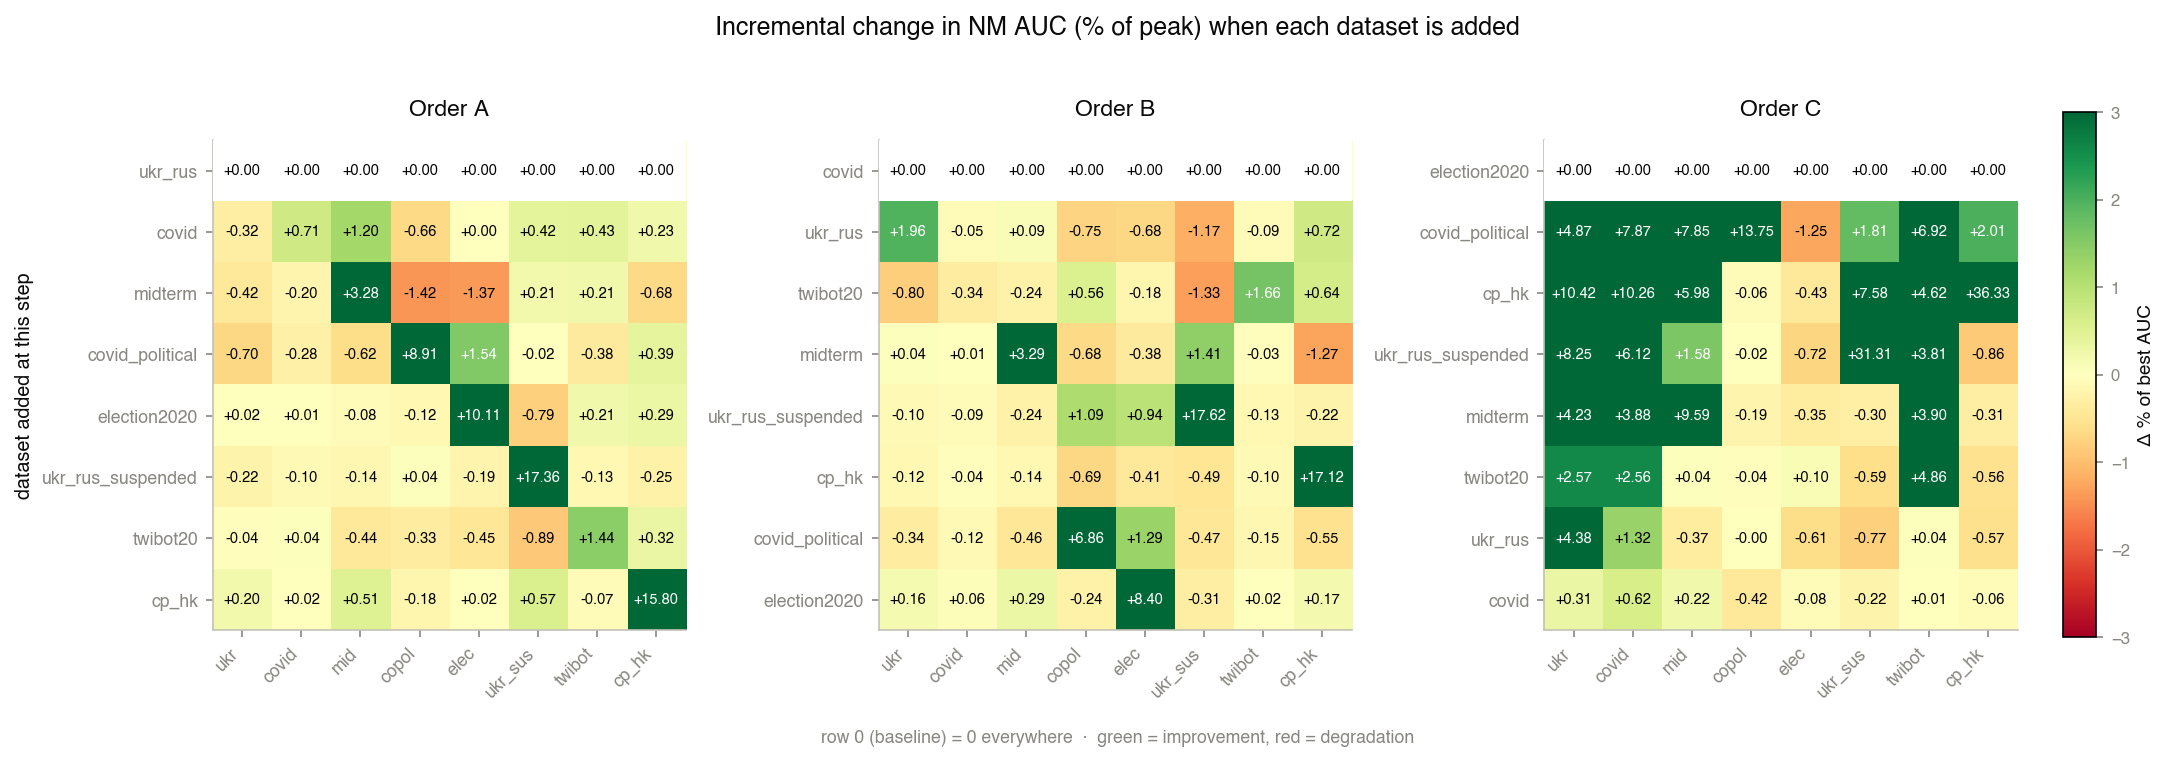

In [115]:
#!/usr/bin/env python3
"""Three heatmaps: order A/B/C showing incremental change in % performance.
Row 0 = 0 everywhere. Subsequent rows show Δ% from previous step."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})


def chrome(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


# Find best AUC per test graph (across all orders, all rungs)
best_per_graph = {}
for col in test_cols:
    best_per_graph[col] = df[col].astype(float).max()

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

for ax_idx, order in enumerate(["A", "B", "C"]):
    ax = axes[ax_idx]
    sub = df[df['order'] == order].sort_values('rung')
    
    # Create matrix: rows=rung (1-8), cols=test_graph
    rungs = sorted(sub['rung'].unique())
    pct_matrix = np.zeros((len(rungs), len(test_cols)))
    added_names = []
    
    for i, rung in enumerate(rungs):
        row_data = sub[sub['rung'] == rung].iloc[0]
        added_names.append(row_data['added'])
        for j, col in enumerate(test_cols):
            auc = float(row_data[col])
            pct = (auc / best_per_graph[col]) * 100
            pct_matrix[i, j] = pct
    
    # Compute delta matrix (change from previous row)
    delta_matrix = np.zeros_like(pct_matrix)
    for i in range(1, len(rungs)):
        delta_matrix[i, :] = pct_matrix[i, :] - pct_matrix[i-1, :]
    # Row 0 is all zeros (baseline)
    
    # Plot heatmap (green=improvement, red=degradation, centered at 0)
    im = ax.imshow(delta_matrix, cmap='RdYlGn', vmin=-3, vmax=3, aspect='auto')
    
    # Draw white rectangles over first row
    for j in range(len(test_cols)):
        rect = Rectangle((j - 0.5, -0.5), 1, 1, linewidth=0, 
                         facecolor='white', zorder=10)
        ax.add_patch(rect)
    
    # Annotations
    for i in range(len(rungs)):
        for j in range(len(test_cols)):
            val = delta_matrix[i, j]
            text_color = "black" if i == 0 else ("white" if abs(val) > 1.5 else "black")
            ax.text(j, i, f"{val:+.2f}", ha="center", va="center", 
                   fontsize=7, color=text_color, fontweight="bold", zorder=11)
    
    # Labels
    short_names = ['ukr', 'covid', 'mid', 'copol', 'elec', 'ukr_sus', 'twibot', 'cp_hk']
    ax.set_xticks(range(len(test_cols)))
    ax.set_xticklabels(short_names, fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(len(rungs)))
    ax.set_yticklabels(added_names, fontsize=8.5)
    
    if ax_idx == 0:
        ax.set_ylabel("dataset added at this step", fontsize=9.5, color=INK)
    ax.set_title(f"Order {order}", fontsize=11, color=INK, fontweight="bold", pad=12)
    
    chrome(ax)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Δ % of best AUC", fontsize=9, color=INK)
cbar.ax.tick_params(colors=MUTED, labelsize=8)

fig.suptitle("Incremental change in NM AUC (% of peak) when each dataset is added",
            fontsize=12, color=INK, fontweight="bold", y=0.98)
fig.text(0.5, 0.01, "row 0 (baseline) = 0 everywhere  ·  green = improvement, red = degradation",
         ha="center", fontsize=8.5, color=MUTED)

plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])
plt.show()

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/3205529652.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])


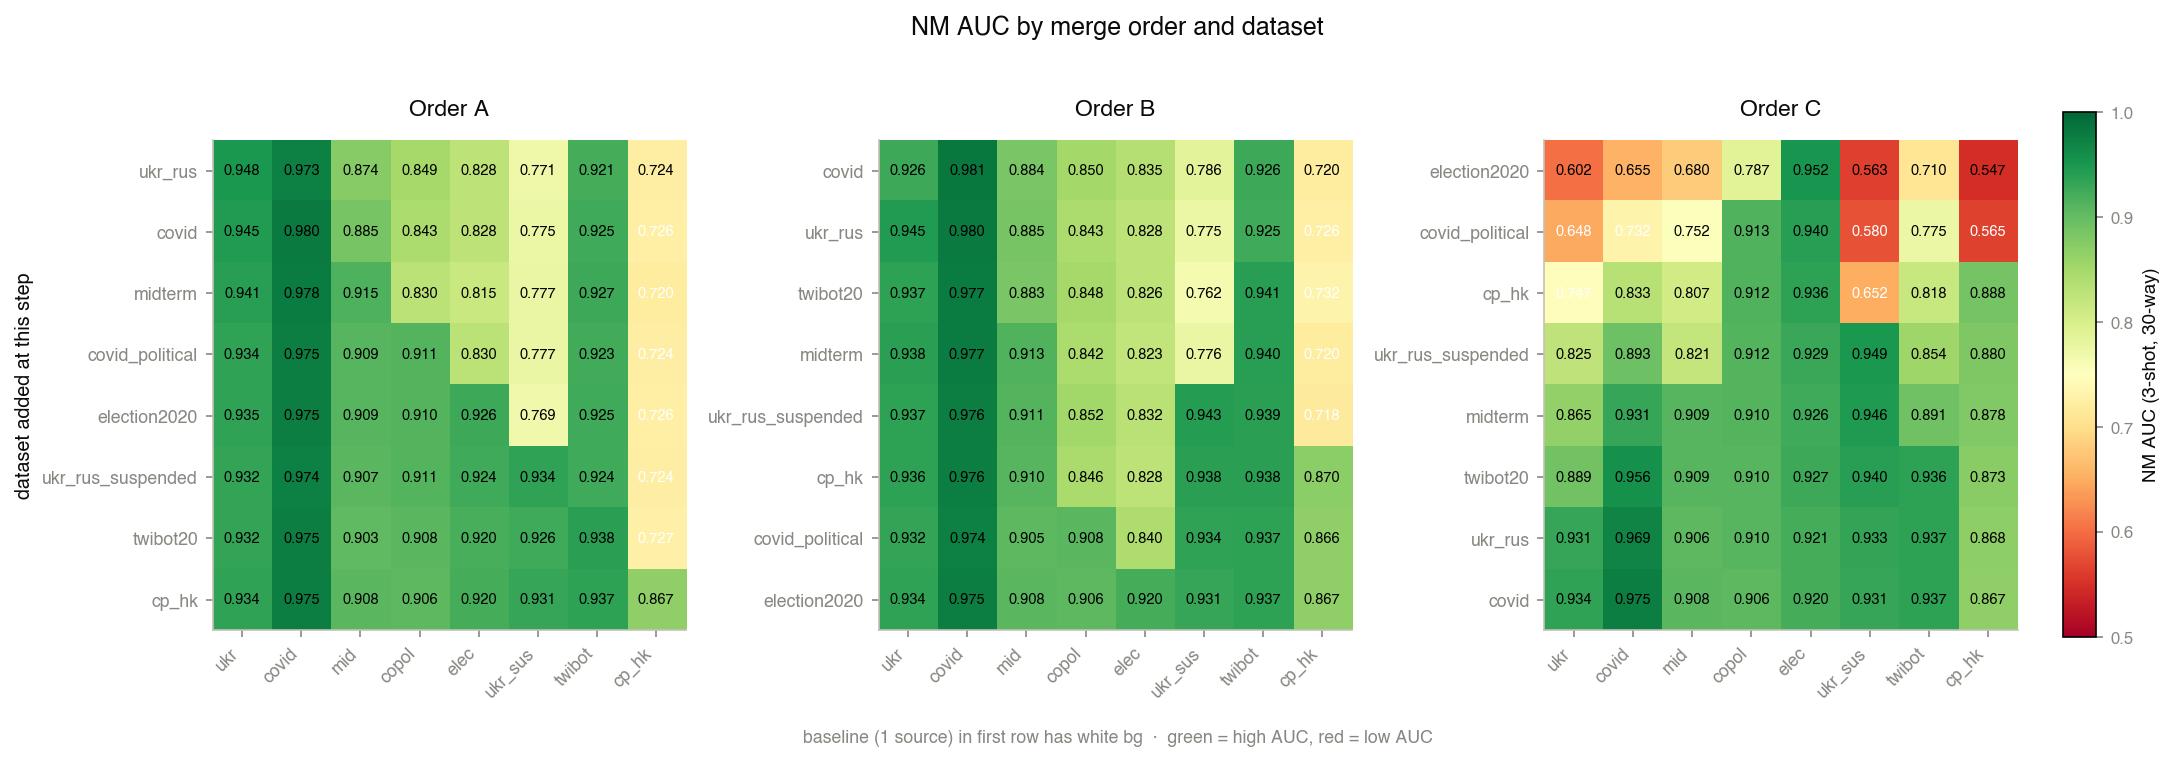

In [129]:
#!/usr/bin/env python3
"""Three heatmaps: order A/B/C with rows=added dataset, cols=test graphs, values=absolute AUC."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})


def chrome(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

for ax_idx, order in enumerate(["A", "B", "C"]):
    ax = axes[ax_idx]
    sub = df[df['order'] == order].sort_values('rung')
    
    # Create matrix: rows=rung (1-8), cols=test_graph
    rungs = sorted(sub['rung'].unique())
    matrix = np.zeros((len(rungs), len(test_cols)))
    added_names = []
    
    for i, rung in enumerate(rungs):
        row_data = sub[sub['rung'] == rung].iloc[0]
        added_names.append(row_data['added'])
        for j, col in enumerate(test_cols):
            matrix[i, j] = float(row_data[col])
    
    # Plot heatmap (greener=better, redder=worse)
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0.5, vmax=1, aspect='auto')
    
    
    # Annotations
    for i in range(len(rungs)):
        for j in range(len(test_cols)):
            val = matrix[i, j]
            text_color = "black" if i == 0 else ("white" if val < 0.75 else "black")
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", 
                   fontsize=7, color=text_color, fontweight="bold", zorder=11)
    
    # Labels
    short_names = ['ukr', 'covid', 'mid', 'copol', 'elec', 'ukr_sus', 'twibot', 'cp_hk']
    ax.set_xticks(range(len(test_cols)))
    ax.set_xticklabels(short_names, fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(len(rungs)))
    ax.set_yticklabels(added_names, fontsize=8.5)
    
    if ax_idx == 0:
        ax.set_ylabel("dataset added at this step", fontsize=9.5, color=INK)
    ax.set_title(f"Order {order}", fontsize=11, color=INK, fontweight="bold", pad=12)
    
    chrome(ax)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("NM AUC (3-shot, 30-way)", fontsize=9, color=INK)
cbar.ax.tick_params(colors=MUTED, labelsize=8)

fig.suptitle("NM AUC by merge order and dataset",
            fontsize=12, color=INK, fontweight="bold", y=0.98)
fig.text(0.5, 0.01, "baseline (1 source) in first row has white bg  ·  "
         "green = high AUC, red = low AUC",
         ha="center", fontsize=8.5, color=MUTED)

plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])
plt.show()

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/486780896.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])


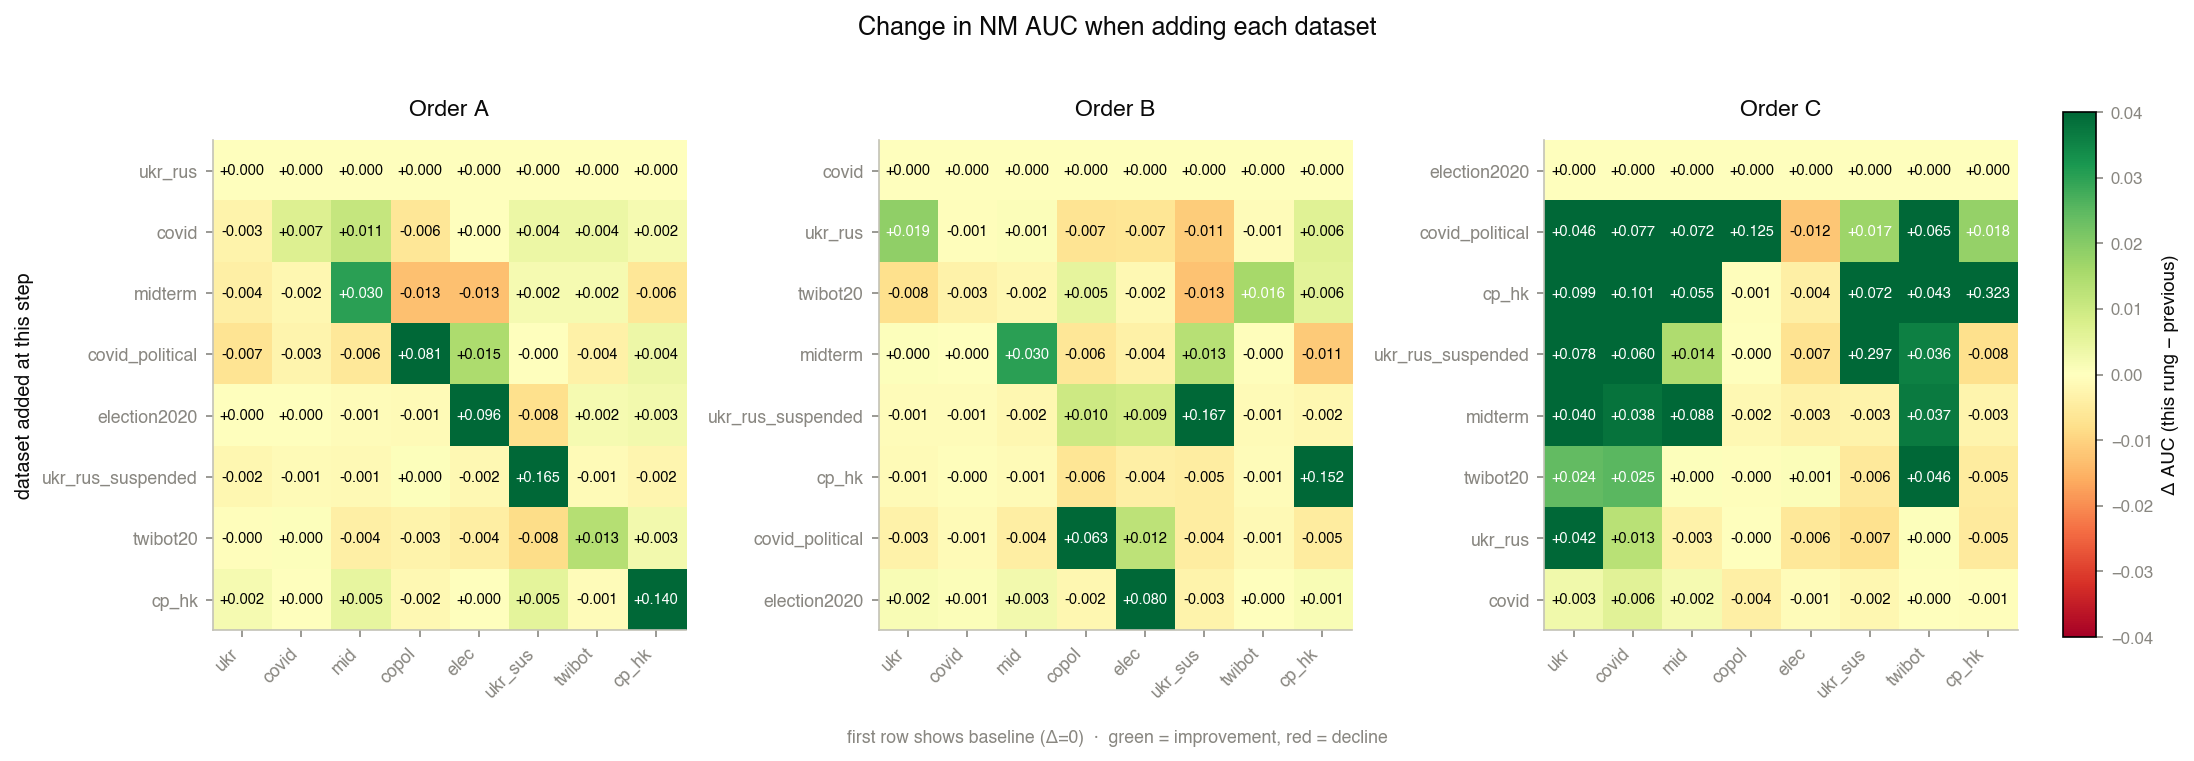

In [120]:
#!/usr/bin/env python3
"""Three heatmaps: order A/B/C with rows=added dataset, cols=test graphs, values=change in AUC."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})


def chrome(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

for ax_idx, order in enumerate(["A", "B", "C"]):
    ax = axes[ax_idx]
    sub = df[df['order'] == order].sort_values('rung')
    
    # Create matrix: rows=rung (1-8), cols=test_graph
    rungs = sorted(sub['rung'].unique())
    matrix = np.zeros((len(rungs), len(test_cols)))
    added_names = []
    
    # Get AUC values for all rungs
    auc_by_rung = {}
    for rung in rungs:
        row_data = sub[sub['rung'] == rung].iloc[0]
        added_names.append(row_data['added'])
        auc_by_rung[rung] = {col: float(row_data[col]) for col in test_cols}
    
    # Compute deltas (change from previous rung)
    prev_rung = None
    for i, rung in enumerate(rungs):
        for j, col in enumerate(test_cols):
            if prev_rung is None:
                matrix[i, j] = 0.0  # Row 0 has no previous, show as 0
            else:
                matrix[i, j] = auc_by_rung[rung][col] - auc_by_rung[prev_rung][col]
        prev_rung = rung
    
    # Plot heatmap (diverging: red=negative change, green=positive change)
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-0.04, vmax=0.04, aspect='auto')
    
    # Annotations
    for i in range(len(rungs)):
        for j in range(len(test_cols)):
            val = matrix[i, j]
            text_color = "white" if abs(val) > 0.015 else "black"
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", 
                   fontsize=7, color=text_color, fontweight="bold", zorder=11)
    
    # Labels
    short_names = ['ukr', 'covid', 'mid', 'copol', 'elec', 'ukr_sus', 'twibot', 'cp_hk']
    ax.set_xticks(range(len(test_cols)))
    ax.set_xticklabels(short_names, fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(len(rungs)))
    ax.set_yticklabels(added_names, fontsize=8.5)
    
    if ax_idx == 0:
        ax.set_ylabel("dataset added at this step", fontsize=9.5, color=INK)
    ax.set_title(f"Order {order}", fontsize=11, color=INK, fontweight="bold", pad=12)
    
    chrome(ax)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Δ AUC (this rung − previous)", fontsize=9, color=INK)
cbar.ax.tick_params(colors=MUTED, labelsize=8)

fig.suptitle("Change in NM AUC when adding each dataset",
            fontsize=12, color=INK, fontweight="bold", y=0.98)
fig.text(0.5, 0.01, "first row shows baseline (Δ=0)  ·  "
         "green = improvement, red = decline",
         ha="center", fontsize=8.5, color=MUTED)

plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])
plt.show()

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/3112509060.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])


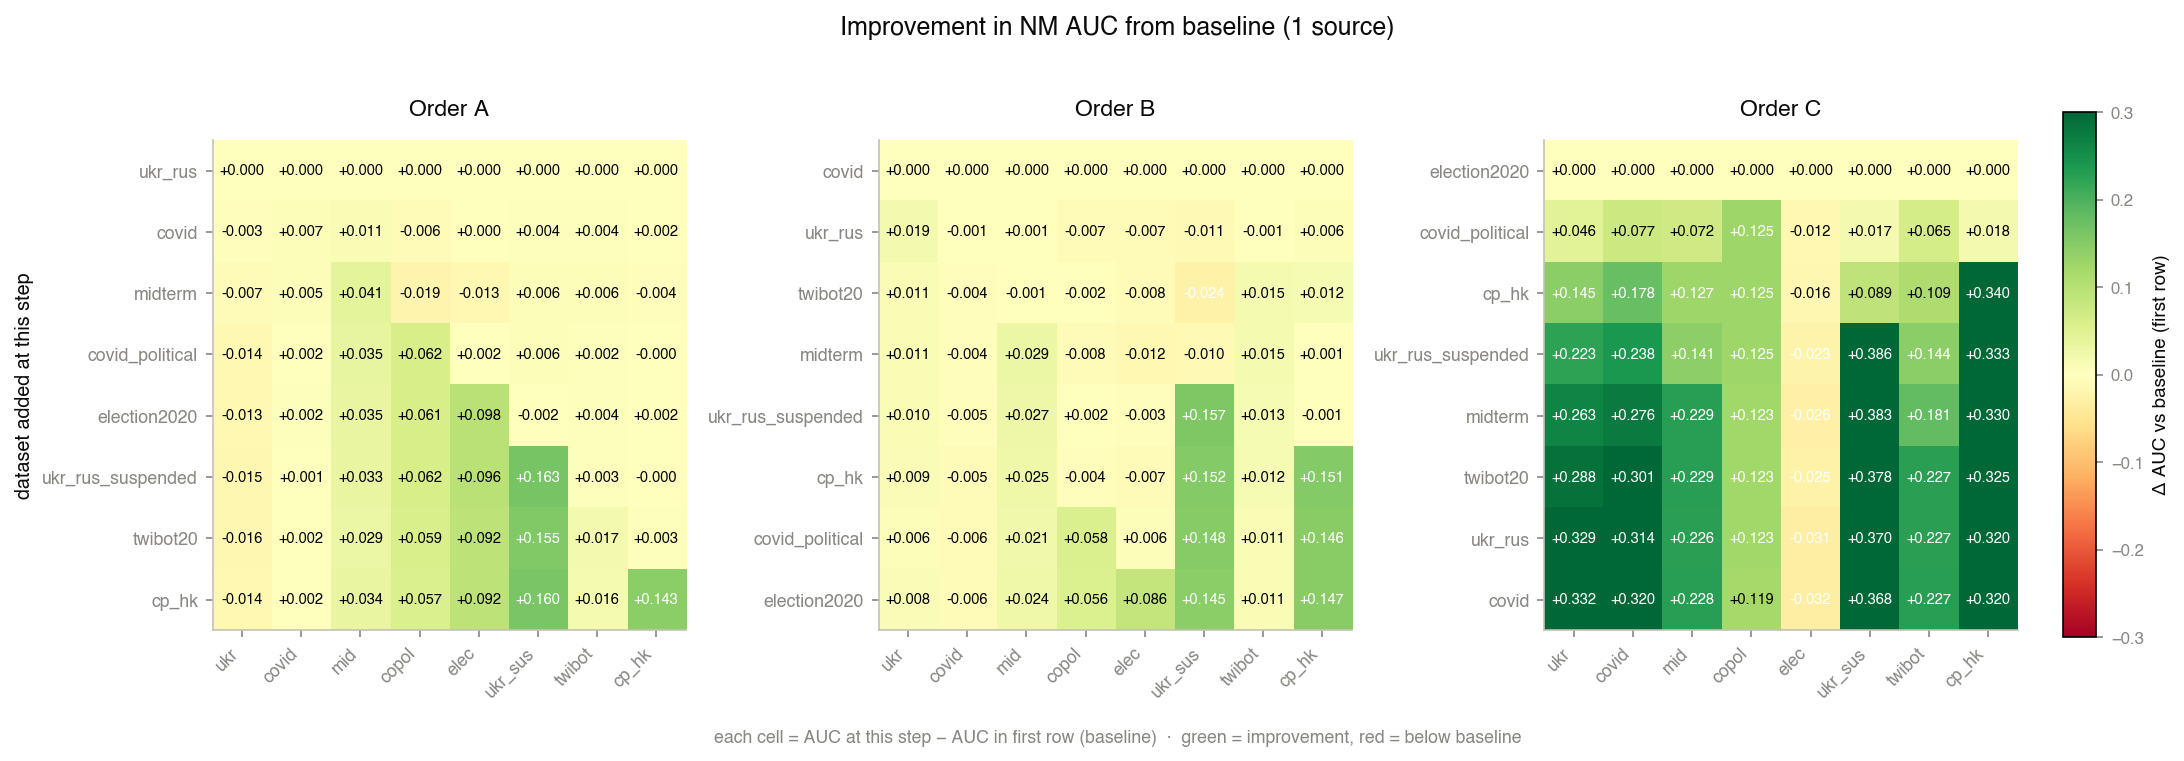

In [128]:
#!/usr/bin/env python3
"""Three heatmaps: order A/B/C with rows=added dataset, cols=test graphs, values=Δ AUC vs baseline."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})


def chrome(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

for ax_idx, order in enumerate(["A", "B", "C"]):
    ax = axes[ax_idx]
    sub = df[df['order'] == order].sort_values('rung')
    
    # Create matrix: rows=rung (1-8), cols=test_graph
    rungs = sorted(sub['rung'].unique())
    matrix = np.zeros((len(rungs), len(test_cols)))
    added_names = []
    
    # Get AUC values for all rungs
    auc_by_rung = {}
    for rung in rungs:
        row_data = sub[sub['rung'] == rung].iloc[0]
        added_names.append(row_data['added'])
        auc_by_rung[rung] = {col: float(row_data[col]) for col in test_cols}
    
    # Get baseline (row 0 / first rung) AUC
    baseline_rung = rungs[0]
    baseline_auc = auc_by_rung[baseline_rung]
    
    # Compute deltas relative to baseline
    for i, rung in enumerate(rungs):
        for j, col in enumerate(test_cols):
            matrix[i, j] = auc_by_rung[rung][col] - baseline_auc[col]
    
    # Plot heatmap (diverging: red=below baseline, green=above baseline)
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-0.3, vmax=0.3, aspect='auto')
    
    # Annotations
    for i in range(len(rungs)):
        for j in range(len(test_cols)):
            val = matrix[i, j]
            text_color = "white" if val < -0.02 or val > 0.12 else "black"
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", 
                   fontsize=7, color=text_color, fontweight="bold", zorder=11)
    
    # Labels
    short_names = ['ukr', 'covid', 'mid', 'copol', 'elec', 'ukr_sus', 'twibot', 'cp_hk']
    ax.set_xticks(range(len(test_cols)))
    ax.set_xticklabels(short_names, fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(len(rungs)))
    ax.set_yticklabels(added_names, fontsize=8.5)
    
    if ax_idx == 0:
        ax.set_ylabel("dataset added at this step", fontsize=9.5, color=INK)
    ax.set_title(f"Order {order}", fontsize=11, color=INK, fontweight="bold", pad=12)
    
    chrome(ax)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Δ AUC vs baseline (first row)", fontsize=9, color=INK)
cbar.ax.tick_params(colors=MUTED, labelsize=8)

fig.suptitle("Improvement in NM AUC from baseline (1 source)",
            fontsize=12, color=INK, fontweight="bold", y=0.98)
fig.text(0.5, 0.01, "each cell = AUC at this step − AUC in first row (baseline)  ·  "
         "green = improvement, red = below baseline",
         ha="center", fontsize=8.5, color=MUTED)

plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])
plt.show()

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/2304632225.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])


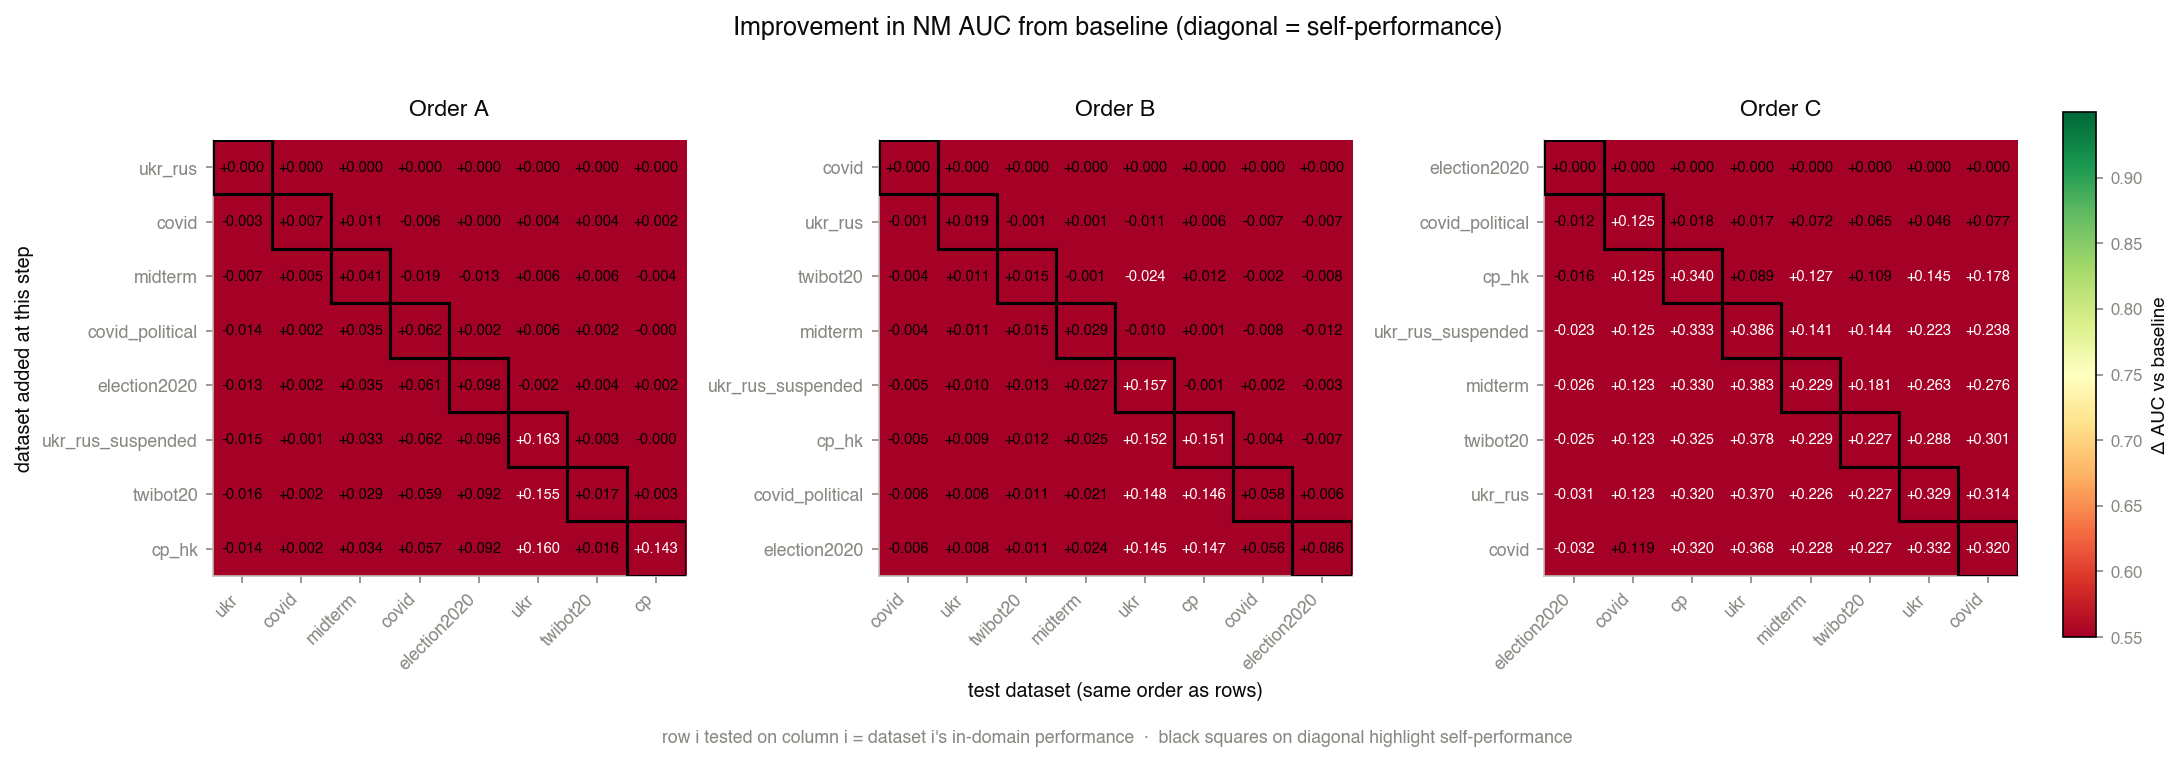

In [ ]:
from matplotlib.colors import TwoSlopeNorm

#!/usr/bin/env python3
"""Three heatmaps: order A/B/C with rows=added dataset, cols=test graphs (same order).
Diagonal shows each dataset's performance when tested on itself."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})


def chrome(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

for ax_idx, order in enumerate(["A", "B", "C"]):
    ax = axes[ax_idx]
    sub = df[df['order'] == order].sort_values('rung')
    
    # Create matrix: rows=rung (1-8), cols=test_graph
    rungs = sorted(sub['rung'].unique())
    added_names = []
    
    # Get AUC values and collect dataset names in order
    auc_by_rung = {}
    for rung in rungs:
        row_data = sub[sub['rung'] == rung].iloc[0]
        added_names.append(row_data['added'])
        auc_by_rung[rung] = {col: float(row_data[col]) for col in test_cols}
    
    # Reorder columns to match row order (datasets added)
    col_order = [KEY2COL.get(name, name) for name in added_names]
    
    # Build matrix in reordered column space
    matrix = np.zeros((len(rungs), len(added_names)))
    
    # Get baseline (row 0 / first rung) AUC
    baseline_rung = rungs[0]
    baseline_auc = auc_by_rung[baseline_rung]
    
    # Compute deltas relative to baseline, in reordered columns
    for i, rung in enumerate(rungs):
        for j, col in enumerate(col_order):
            matrix[i, j] = auc_by_rung[rung].get(col, np.nan) - baseline_auc.get(col, 0)
            
    norm = TwoSlopeNorm(vmin=-0.08, vcenter=0.75, vmax=0.2)
    vmin=-0.08, =0, vmax=0.20
    
    # Plot heatmap (diverging: red=below baseline, green=above baseline)
    im = ax.imshow(matrix, cmap='RdYlGn', norm=norm, aspect='auto')
    
    # Draw diagonal to highlight self-performance
    for i in range(min(len(rungs), len(added_names))):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, 
                                   fill=False, edgecolor='black', lw=1.5, zorder=12))
    
    # Annotations
    for i in range(len(rungs)):
        for j in range(len(col_order)):
            val = matrix[i, j]
            text_color = "white" if val < -0.02 or val > 0.12 else "black"
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", 
                   fontsize=7, color=text_color, fontweight="bold", zorder=11)
    
    # Labels
    short_names = ['ukr', 'covid', 'mid', 'copol', 'elec', 'ukr_sus', 'twibot', 'cp_hk']
    col_short = [name.split('_')[0] for name in added_names]
    
    ax.set_xticks(range(len(col_order)))
    ax.set_xticklabels(col_short, fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(len(rungs)))
    ax.set_yticklabels(added_names, fontsize=8.5)
    
    if ax_idx == 0:
        ax.set_ylabel("dataset added at this step", fontsize=9.5, color=INK)
    if ax_idx == 1:
        ax.set_xlabel("test dataset (same order as rows)", fontsize=9.5, color=INK)
    ax.set_title(f"Order {order}", fontsize=11, color=INK, fontweight="bold", pad=12)
    
    chrome(ax)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Δ AUC vs baseline", fontsize=9, color=INK)
cbar.ax.tick_params(colors=MUTED, labelsize=8)

fig.suptitle("Improvement in NM AUC from baseline (diagonal = self-performance)",
            fontsize=12, color=INK, fontweight="bold", y=0.98)
fig.text(0.5, 0.01, "row i tested on column i = dataset i's in-domain performance  ·  "
         "black squares on diagonal highlight self-performance",
         ha="center", fontsize=8.5, color=MUTED)

plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])
plt.show()

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/2243554580.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])


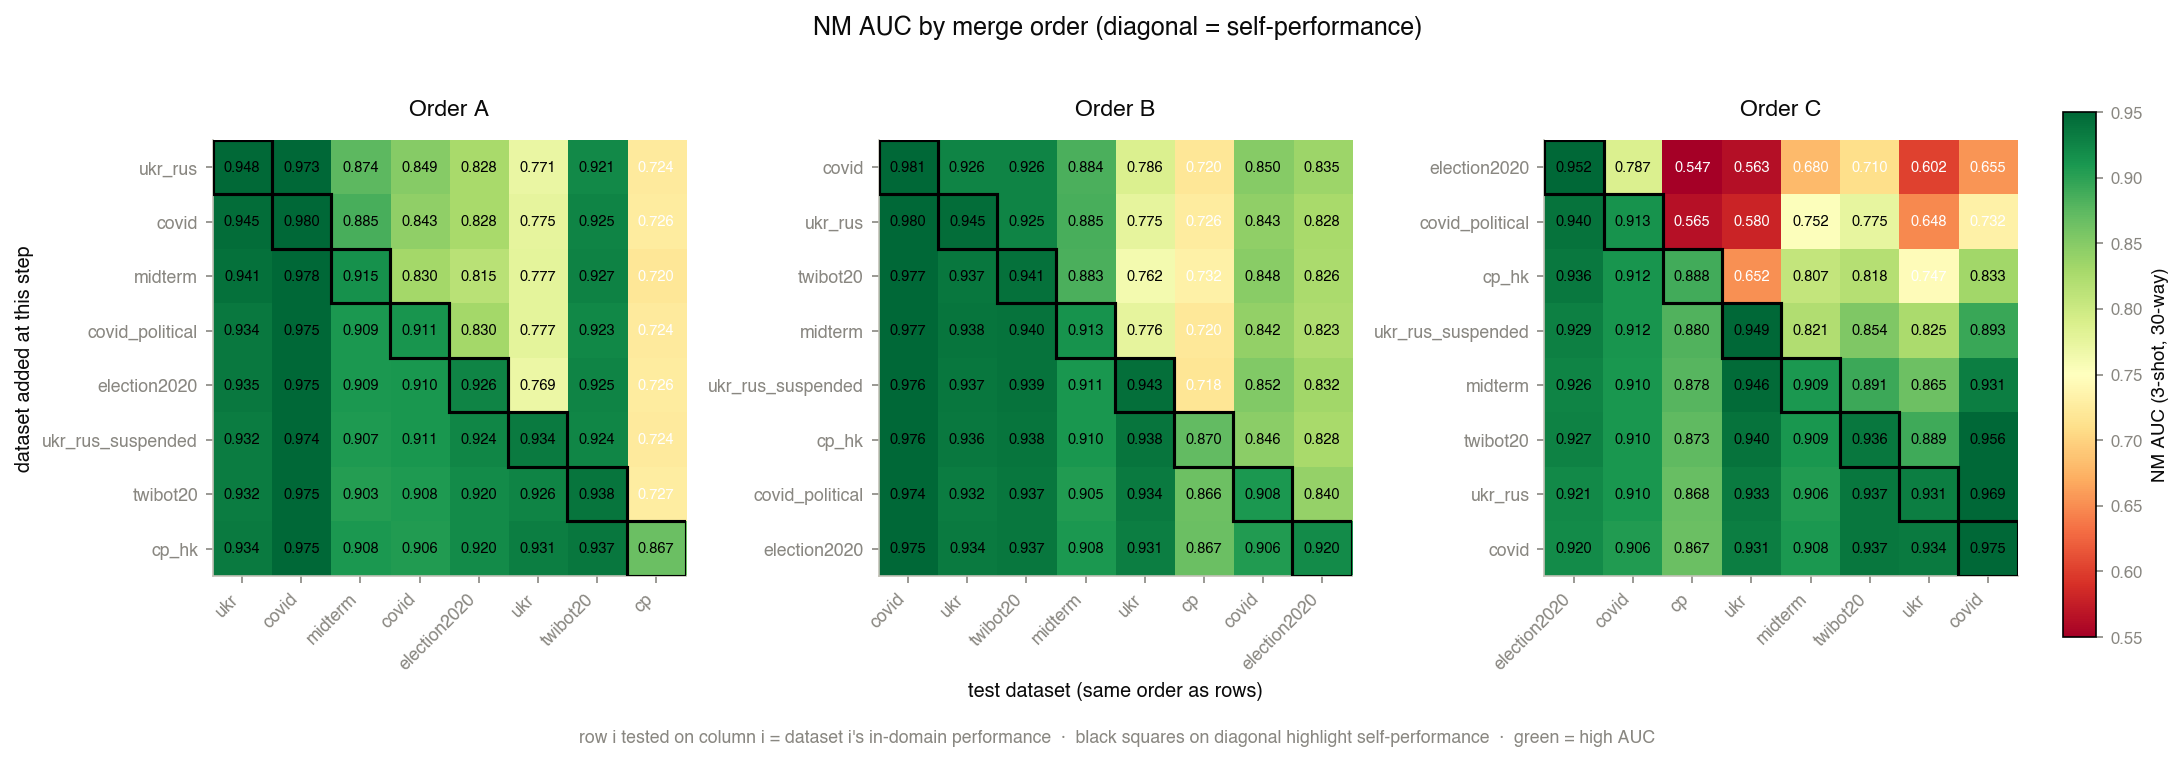

In [150]:
#!/usr/bin/env python3
"""Three heatmaps: order A/B/C with rows=added dataset, cols=test graphs (same order).
Absolute AUC values. Diagonal shows each dataset's performance when tested on itself."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})


def chrome(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

for ax_idx, order in enumerate(["A", "B", "C"]):
    ax = axes[ax_idx]
    sub = df[df['order'] == order].sort_values('rung')
    
    # Create matrix: rows=rung (1-8), cols=test_graph
    rungs = sorted(sub['rung'].unique())
    added_names = []
    
    # Get AUC values and collect dataset names in order
    auc_by_rung = {}
    for rung in rungs:
        row_data = sub[sub['rung'] == rung].iloc[0]
        added_names.append(row_data['added'])
        auc_by_rung[rung] = {col: float(row_data[col]) for col in test_cols}
    
    # Reorder columns to match row order (datasets added)
    col_order = [KEY2COL.get(name, name) for name in added_names]
    
    # Build matrix in reordered column space with absolute AUC
    matrix = np.zeros((len(rungs), len(added_names)))
    
    # Compute AUC values in reordered columns
    for i, rung in enumerate(rungs):
        for j, col in enumerate(col_order):
            matrix[i, j] = auc_by_rung[rung].get(col, np.nan)
    
    # Plot heatmap (greener=better)
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0.55, vmax=0.95, aspect='auto')
    
    # Draw diagonal to highlight self-performance
    for i in range(min(len(rungs), len(added_names))):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, 
                                   fill=False, edgecolor='black', lw=1.5, zorder=12))
    
    # Annotations
    for i in range(len(rungs)):
        for j in range(len(col_order)):
            val = matrix[i, j]
            text_color = "white" if val < 0.75 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", 
                   fontsize=7, color=text_color, fontweight="bold", zorder=11)
    
    # Labels
    col_short = [name.split('_')[0] for name in added_names]
    
    ax.set_xticks(range(len(col_order)))
    ax.set_xticklabels(col_short, fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(len(rungs)))
    ax.set_yticklabels(added_names, fontsize=8.5)
    
    if ax_idx == 0:
        ax.set_ylabel("dataset added at this step", fontsize=9.5, color=INK)
    if ax_idx == 1:
        ax.set_xlabel("test dataset (same order as rows)", fontsize=9.5, color=INK)
    ax.set_title(f"Order {order}", fontsize=11, color=INK, fontweight="bold", pad=12)
    
    chrome(ax)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("NM AUC (3-shot, 30-way)", fontsize=9, color=INK)
cbar.ax.tick_params(colors=MUTED, labelsize=8)

fig.suptitle("NM AUC by merge order (diagonal = self-performance)",
            fontsize=12, color=INK, fontweight="bold", y=0.98)
fig.text(0.5, 0.01, "row i tested on column i = dataset i's in-domain performance  ·  "
         "black squares on diagonal highlight self-performance  ·  green = high AUC",
         ha="center", fontsize=8.5, color=MUTED)

plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])
plt.show()

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/4028073388.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])


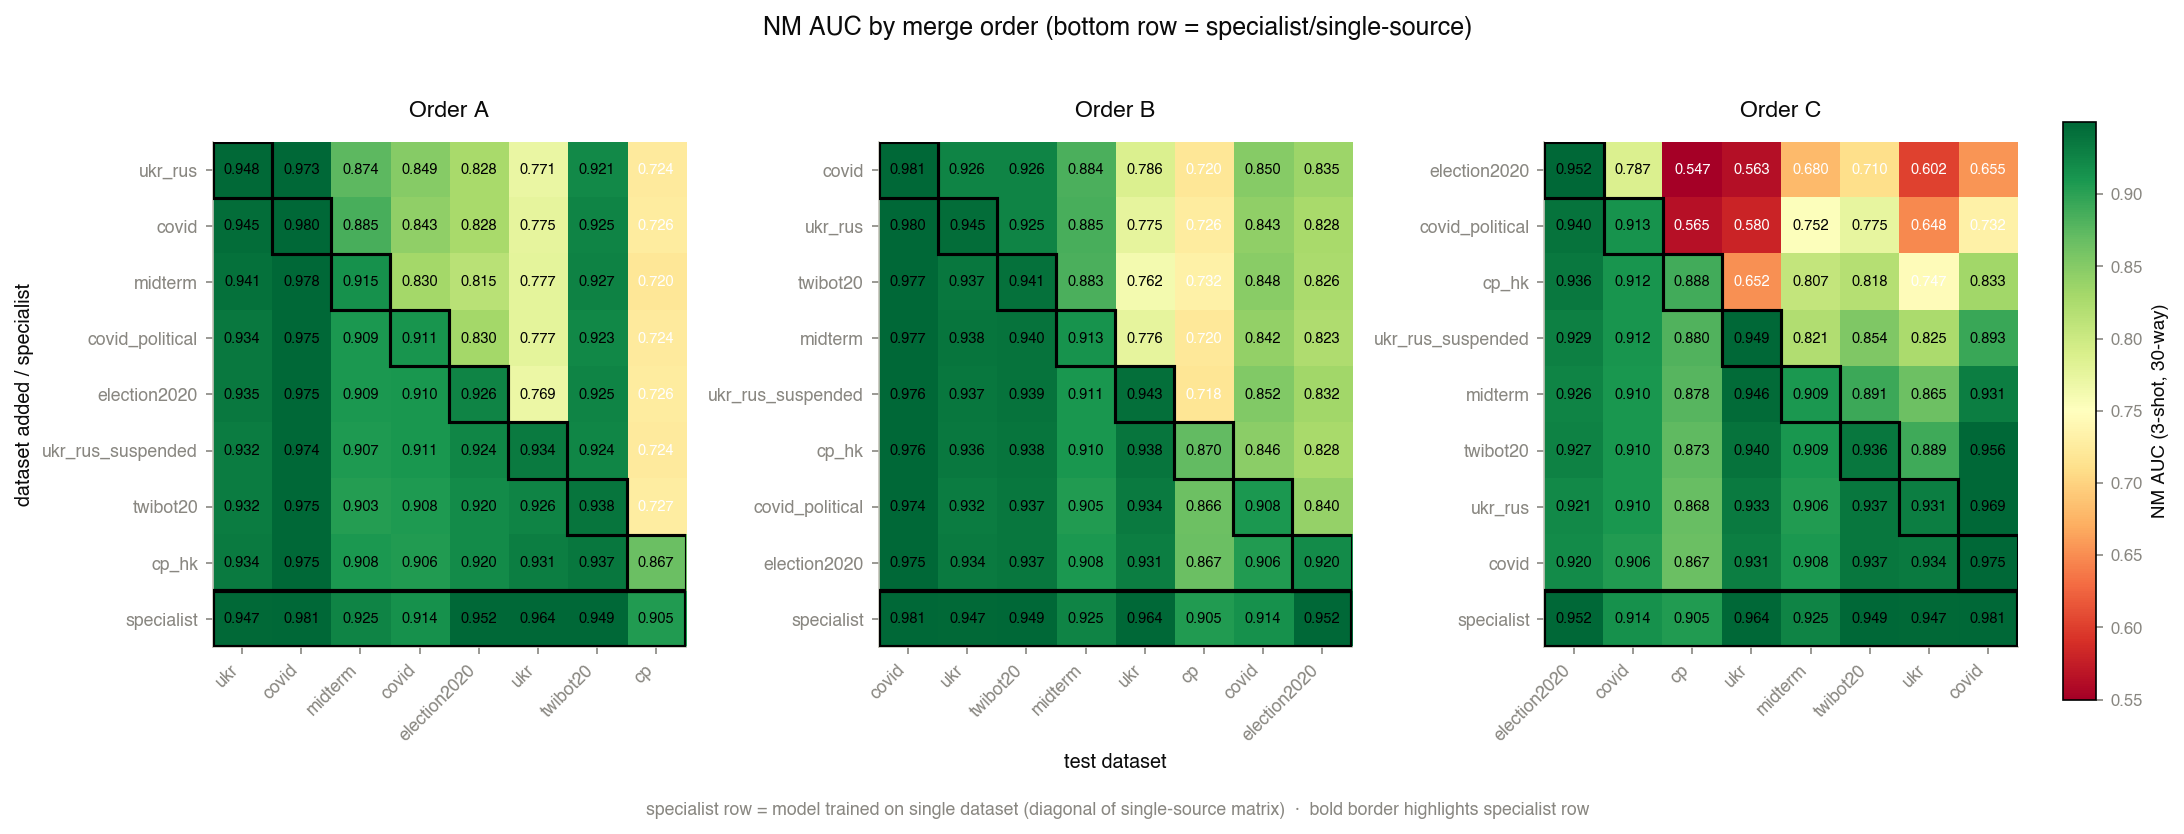

In [159]:
#!/usr/bin/env python3
"""Three heatmaps with specialist row showing single-source AUC."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})


def chrome(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


# Load specialist data (single-source AUC)
specialist_df = pd.read_csv("/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/"
                             "nm_single_source_matrix/data/nm_single_source_matrix.csv",
                             index_col='train_graph')

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), dpi=150)

for ax_idx, order in enumerate(["A", "B", "C"]):
    ax = axes[ax_idx]
    sub = df[df['order'] == order].sort_values('rung')
    
    # Create matrix: rows=rung (1-8), cols=test_graph
    rungs = sorted(sub['rung'].unique())
    added_names = []
    
    # Get AUC values and collect dataset names in order
    auc_by_rung = {}
    for rung in rungs:
        row_data = sub[sub['rung'] == rung].iloc[0]
        added_names.append(row_data['added'])
        auc_by_rung[rung] = {col: float(row_data[col]) for col in test_cols}
    
    # Reorder columns to match row order (datasets added)
    col_order = [KEY2COL.get(name, name) for name in added_names]
    
    # Build matrix in reordered column space
    matrix = np.zeros((len(rungs), len(added_names)))
    
    for i, rung in enumerate(rungs):
        for j, col in enumerate(col_order):
            matrix[i, j] = auc_by_rung[rung].get(col, np.nan)
    
    # Add specialist row (diagonal of single-source matrix)
    specialist_row = np.array([specialist_df.loc[col, col] for col in col_order])
    matrix = np.vstack([matrix, specialist_row])
    added_names_with_spec = added_names + ["specialist"]
    
    # Set colormap with vcenter
    norm = TwoSlopeNorm(vmin=0.55, vcenter=0.75, vmax=0.95)
    im = ax.imshow(matrix, cmap='RdYlGn', norm=norm, aspect='auto')
    
    # Draw diagonal to highlight self-performance
    for i in range(min(len(rungs), len(added_names))):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, 
                                   fill=False, edgecolor='black', lw=1.5, zorder=12))
    
    # Highlight specialist row with bold border
    ax.add_patch(plt.Rectangle((-0.5, len(rungs) - 0.5), len(added_names), 1,
                              fill=False, edgecolor='black', lw=2, zorder=12))
    
    # Annotations
    for i in range(len(matrix)):
        for j in range(len(col_order)):
            val = matrix[i, j]
            text_color = "white" if val < 0.75 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", 
                   fontsize=7, color=text_color, fontweight="bold", zorder=11)
    
    # Labels
    col_short = [name.split('_')[0] for name in added_names]
    
    ax.set_xticks(range(len(col_order)))
    ax.set_xticklabels(col_short, fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(len(added_names_with_spec)))
    ax.set_yticklabels(added_names_with_spec, fontsize=8.5)
    
    if ax_idx == 0:
        ax.set_ylabel("dataset added / specialist", fontsize=9.5, color=INK)
    if ax_idx == 1:
        ax.set_xlabel("test dataset", fontsize=9.5, color=INK)
    ax.set_title(f"Order {order}", fontsize=11, color=INK, fontweight="bold", pad=12)
    
    chrome(ax)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("NM AUC (3-shot, 30-way)", fontsize=9, color=INK)
cbar.ax.tick_params(colors=MUTED, labelsize=8)

fig.suptitle("NM AUC by merge order (bottom row = specialist/single-source)",
            fontsize=12, color=INK, fontweight="bold", y=0.98)
fig.text(0.5, 0.01, "specialist row = model trained on single dataset (diagonal of single-source matrix)  ·  "
         "bold border highlights specialist row",
         ha="center", fontsize=8.5, color=MUTED)

plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])
plt.show()

In [166]:
import pandas as pd

# Load the order-robustness data
df_order = pd.read_csv("/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/"
                        "nm_ladder_order_robustness/data/nm_ladder_order_robustness_long.csv")

# Load specialist data
specialist_df = pd.read_csv("/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/"
                             "nm_single_source_matrix/data/nm_single_source_matrix.csv",
                             index_col='train_graph')

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

# Create specialist rows (one per test column, diagonal values)
specialist_rows = []
for train_graph in specialist_df.index:
    row = {
        'order': 'specialist',
        'rung': 9,
        'n_sources': 1,
        'graph': train_graph,
        'sources': train_graph,
        'added': train_graph,
        'in_training': 1,
    }
    # Add AUCs: for specialist, use the diagonal (train_graph tested on itself)
    for col in test_cols:
        row[col] = specialist_df.loc[train_graph, col]
    specialist_rows.append(row)

specialist_df_rows = pd.DataFrame(specialist_rows)

# Merge
jdf = pd.concat([df_order, specialist_df_rows], ignore_index=True)

jdf

,order,rung,n_sources,test_graph,test_canonical,auc,entry_rung,rel_to_entry,in_training,added,...,provenance,graph,ukr_rus_twitter,covid19_twitter,midterm,covid_political,election2020,ukr_rus_suspended,twibot20,cp_hk_twitter
0,A,1,1,ukr_rus_twitter,ukraine,0.948,1.0,0.0,1,ukr_rus,...,order-A ladder rung 1 (nm_ladder_full.csv),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,1,1,covid19_twitter,covid,0.973,2.0,-1.0,0,ukr_rus,...,order-A ladder rung 1 (nm_ladder_full.csv),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A,1,1,midterm,midterm,0.874,3.0,-2.0,0,ukr_rus,...,order-A ladder rung 1 (nm_ladder_full.csv),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A,1,1,covid_political,covid-political,0.849,4.0,-3.0,0,ukr_rus,...,order-A ladder rung 1 (nm_ladder_full.csv),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A,1,1,election2020,election2020-political,0.828,5.0,-4.0,0,ukr_rus,...,order-A ladder rung 1 (nm_ladder_full.csv),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,specialist,9,1,NaN,NaN,NaN,NaN,NaN,1,covid_political,...,NaN,covid_political,0.6301,0.6985,0.6878,0.9145,0.7833,0.5510,0.7374,0.5444
196,specialist,9,1,NaN,NaN,NaN,NaN,NaN,1,election2020,...,NaN,election2020,0.6018,0.6551,0.6804,0.7872,0.9519,0.5627,0.7096,0.5475
197,specialist,9,1,NaN,NaN,NaN,NaN,NaN,1,ukr_rus_suspended,...,NaN,ukr_rus_suspended,0.7695,0.8307,0.7247,0.7325,0.7275,0.9640,0.7647,0.6225
198,specialist,9,1,NaN,NaN,NaN,NaN,NaN,1,twibot20,...,NaN,twibot20,0.8688,0.9473,0.8600,0.8431,0.8025,0.7115,0.9487,0.6895


/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/3734586171.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])


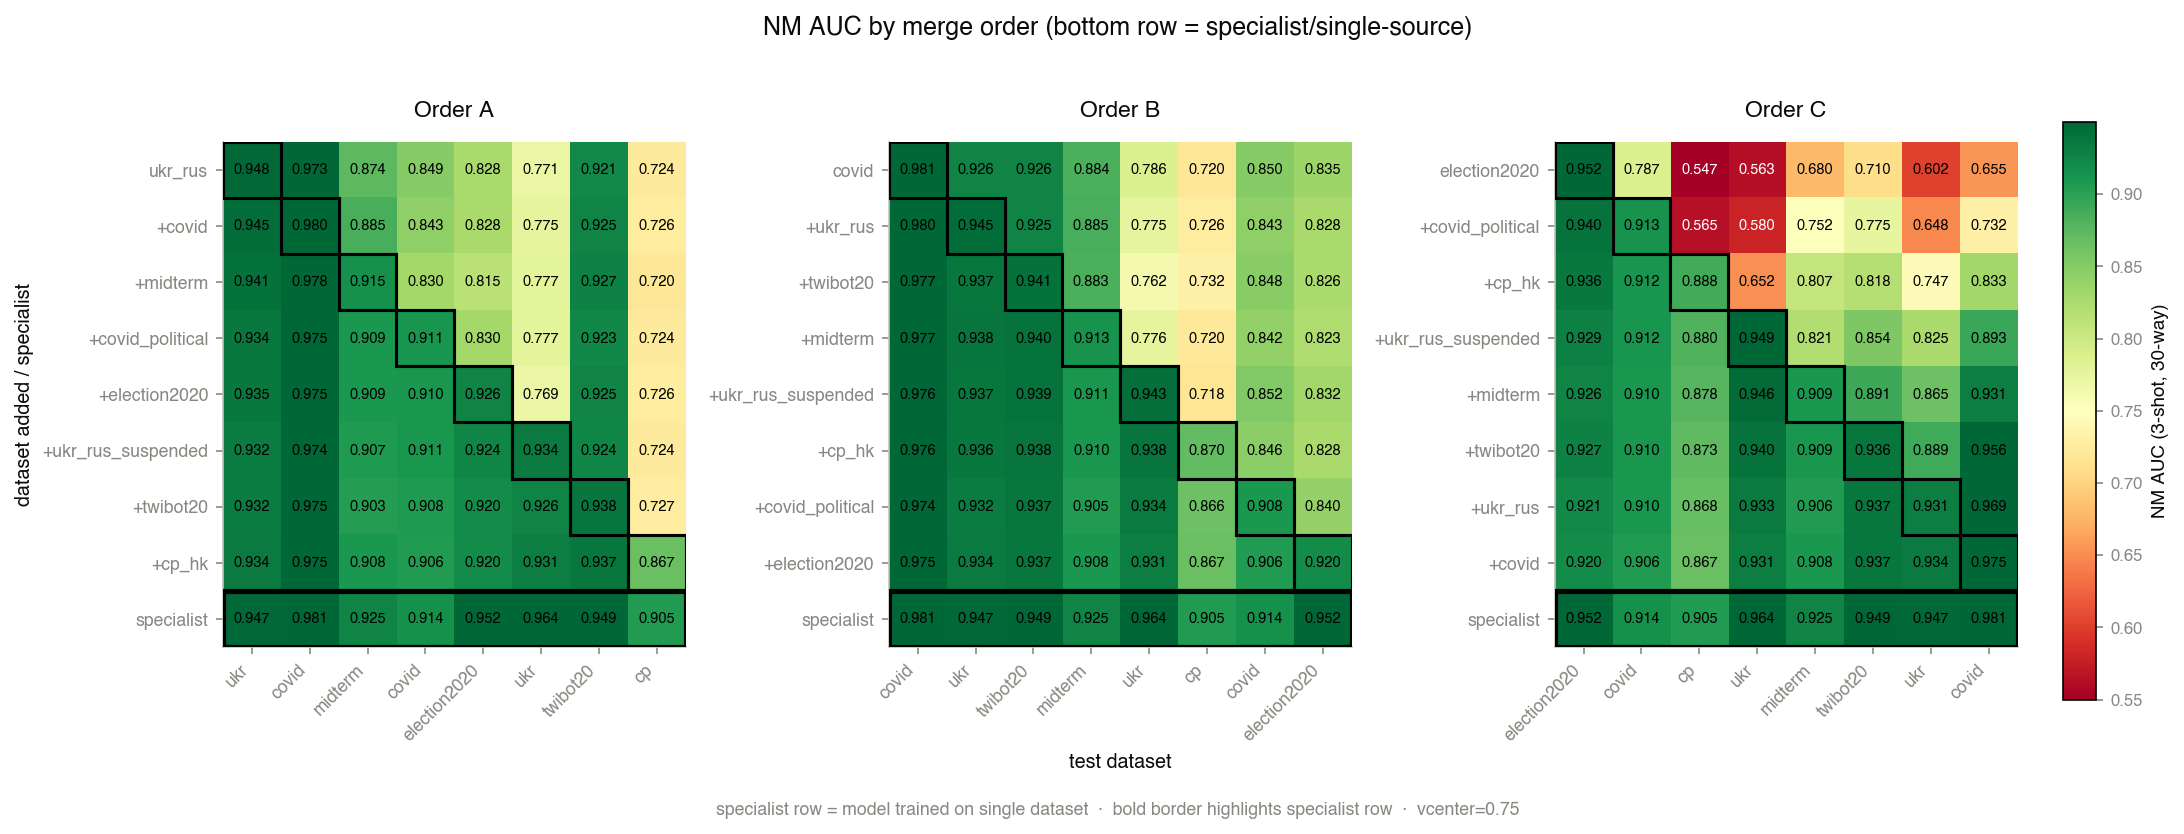

In [302]:
#!/usr/bin/env python3
"""Three heatmaps with specialist row at bottom (rung 9)."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import pandas as pd
import numpy as np

# Load specialist data
specialist_df = pd.read_csv("/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/"
                             "nm_single_source_matrix/data/nm_single_source_matrix.csv",
                             index_col='train_graph')

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

specialist_rows = []
for order_val in ['A', 'B', 'C']:
    row = {
        'order': order_val,
        'rung': 9,
        'n_sources': 8,  # All datasets
        'added': 'specialist',  # Single label
        'sources': ' '.join(KEY2COL.keys()),  # All sources
        'status': 'specialist',
        'provenance': 'nm_single_source_matrix.csv',
    }
    # For specialist row, take diagonal (each dataset tested on itself)
    for train_graph_short, train_graph_col in KEY2COL.items():
        row[train_graph_col] = specialist_df.loc[train_graph_col, train_graph_col]
    specialist_rows.append(row)

specialist_data = pd.DataFrame(specialist_rows)
jdf = pd.concat([df, specialist_data], ignore_index=True)

test_cols = ['ukr_rus_twitter', 'covid19_twitter', 'midterm', 'covid_political',
             'election2020', 'ukr_rus_suspended', 'twibot20', 'cp_hk_twitter']

KEY2COL = {
    'ukr_rus': 'ukr_rus_twitter', 'covid': 'covid19_twitter', 'midterm': 'midterm',
    'covid_political': 'covid_political', 'election2020': 'election2020',
    'ukr_rus_suspended': 'ukr_rus_suspended', 'twibot20': 'twibot20',
    'cp_hk': 'cp_hk_twitter',
}

INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})


def chrome(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), dpi=150)

for ax_idx, order in enumerate(["A", "B", "C"]):
    ax = axes[ax_idx]
    sub = jdf[jdf['order'] == order].sort_values('rung')
    
    # Create matrix: rows=rung (1-9), cols=test_graph
    rungs = sorted(sub['rung'].unique())
    added_names = []
    
    # Get AUC values and collect dataset names in order
    auc_by_rung = {}
    for rung in rungs:
        row_data = sub[sub['rung'] == rung].iloc[0]
        if row_data['added'] != 'specialist':  # Skip specialist in names
            added_names.append(row_data['added'])
        auc_by_rung[rung] = {col: float(row_data[col]) for col in test_cols}

    # Reorder columns to match row order (only non-specialist datasets)
    col_order = [KEY2COL.get(name, name) for name in added_names]

    # Build matrix (including specialist row, but with same columns as others)
    matrix = np.zeros((len(rungs), len(col_order)))

    for i, rung in enumerate(rungs):
        for j, col in enumerate(col_order):
            matrix[i, j] = auc_by_rung[rung].get(col, np.nan)

    # Build y-axis labels (including specialist)
    y_labels = added_names + ['specialist']
    
    for i, rung in enumerate(rungs):
        for j, col in enumerate(col_order):
            matrix[i, j] = auc_by_rung[rung].get(col, np.nan)
    
    # Set colormap with vcenter
    norm = TwoSlopeNorm(vmin=0.55, vcenter=0.75, vmax=0.95)
    im = ax.imshow(matrix, cmap='RdYlGn', norm=norm, aspect='auto')
    
    # Draw diagonal to highlight self-performance (skip last specialist row)
    for i in range(min(len(rungs), len(added_names))):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, 
                                   fill=False, edgecolor='black', lw=1.5, zorder=12))
    
    # Highlight specialist row with bold border
    spec_row_idx = len(rungs) - 1
    ax.add_patch(plt.Rectangle((-0.5, spec_row_idx - 0.5), len(col_order), 1,
                            fill=False, edgecolor='black', lw=2.5, zorder=12))
    
    # Annotations
    for i in range(len(matrix)):
        for j in range(len(col_order)):
            val = matrix[i, j]
            text_color = "white" if val < 0.6 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", 
                   fontsize=7, color=text_color, fontweight="bold", zorder=11)
    
    # Labels
    col_short = [name.split('_')[0] for name in added_names]

    ax.set_xticks(range(len(col_order)))
    ax.set_xticklabels(col_short, fontsize=8, rotation=45, ha="right")

    # Y-axis labels: added datasets + specialist
    y_labels = added_names + ['specialist']
    y_labels = [('+'*(i>0 and i < len(y_labels)-1))+l for i, l in enumerate(y_labels)]
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=8.5)
    
    if ax_idx == 0:
        ax.set_ylabel("dataset added / specialist", fontsize=9.5, color=INK)
    if ax_idx == 1:
        ax.set_xlabel("test dataset", fontsize=9.5, color=INK)
    ax.set_title(f"Order {order}", fontsize=11, color=INK, fontweight="bold", pad=12)
    
    chrome(ax)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("NM AUC (3-shot, 30-way)", fontsize=9, color=INK)
cbar.ax.tick_params(colors=MUTED, labelsize=8)

fig.suptitle("NM AUC by merge order (bottom row = specialist/single-source)",
            fontsize=12, color=INK, fontweight="bold", y=0.98)
fig.text(0.5, 0.01, "specialist row = model trained on single dataset  ·  "
         "bold border highlights specialist row  ·  vcenter=0.75",
         ha="center", fontsize=8.5, color=MUTED)

plt.tight_layout(rect=[0, 0.035, 0.91, 0.96])
plt.show()

In [308]:
specialist_df.loc['interleaved-8'] = jdf[jdf.rung.eq(8)][specialist_df.columns].iloc[0]

In [ ]:
specialist_df['avg'] = specialist_df.mean(1)

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/1546557256.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  specialist_df['avg'] = specialist_df.mean(1)


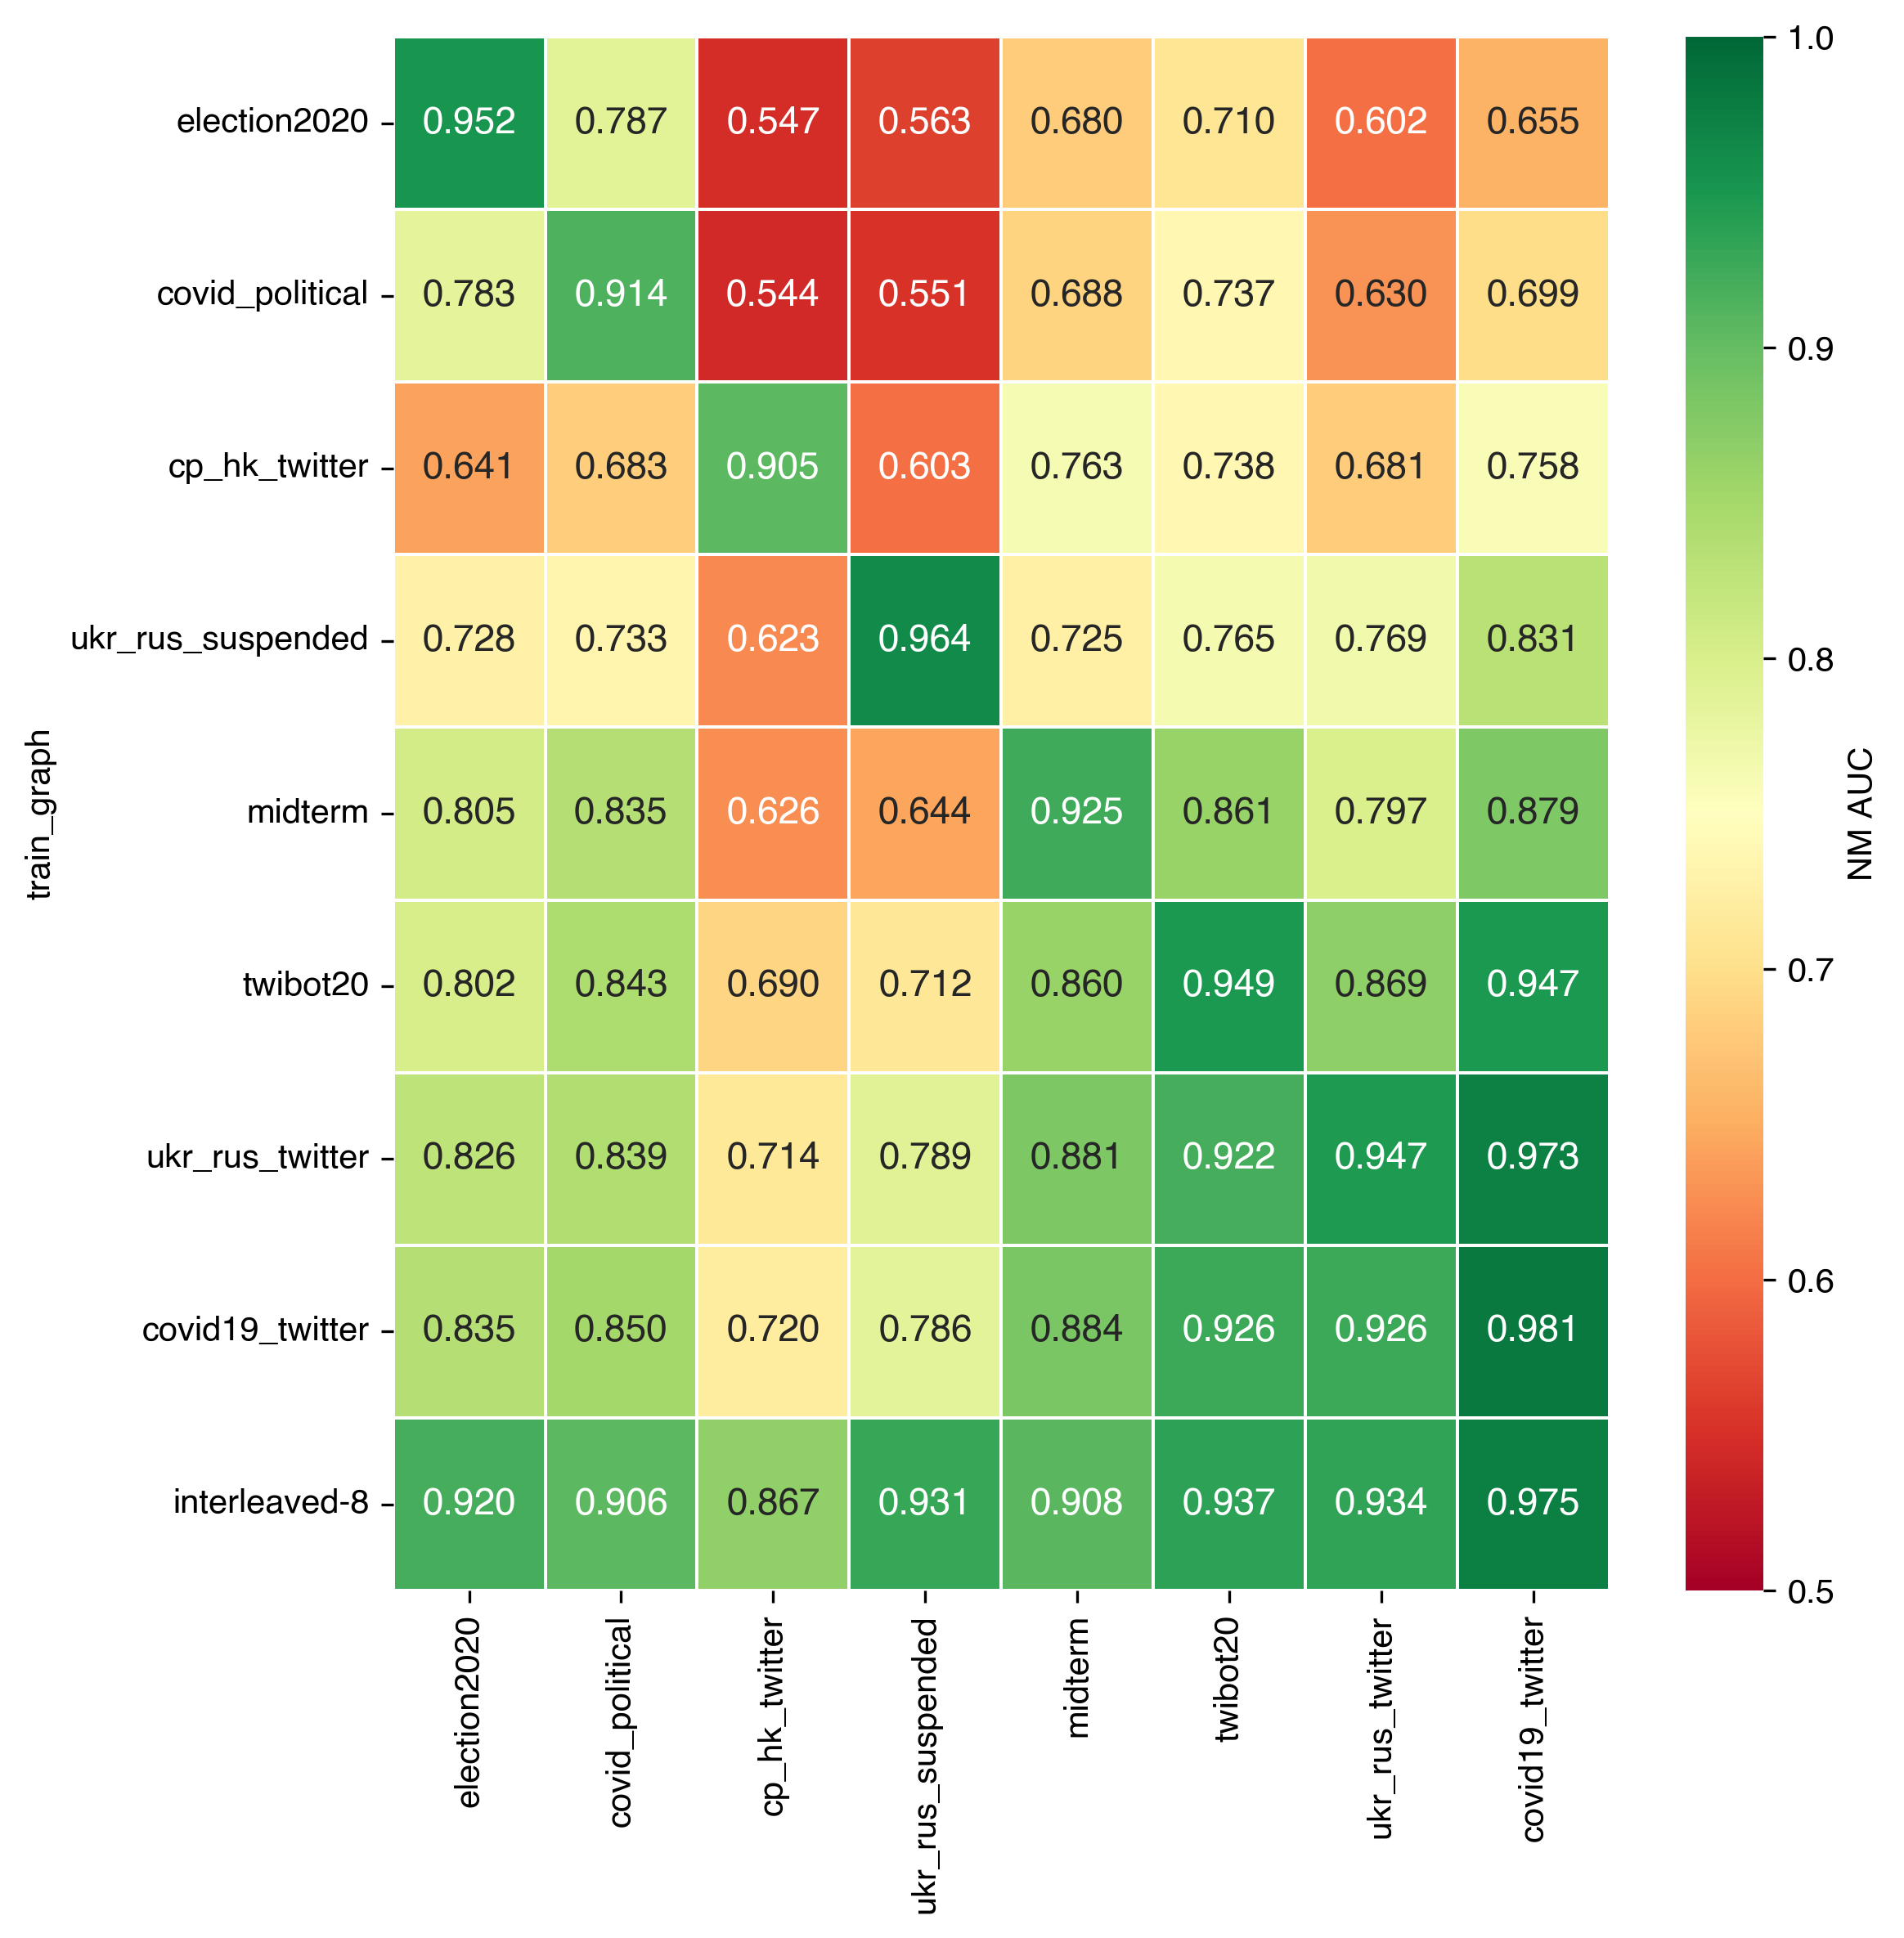

In [325]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(8, 8), dpi=300)

pdf = specialist_df.sort_values('avg')
pdf = pdf[pdf.index[:-1]]
sns.heatmap(pdf, annot=True, cmap='RdYlGn', vmin=0.5, vmax=1,
            cbar_kws={'label': 'NM AUC'}, fmt='.3f', 
            annot_kws={'fontsize': 11},  # Annotation text size
            linewidths=0.5)  # Cell borders

plt.tight_layout()
plt.show()

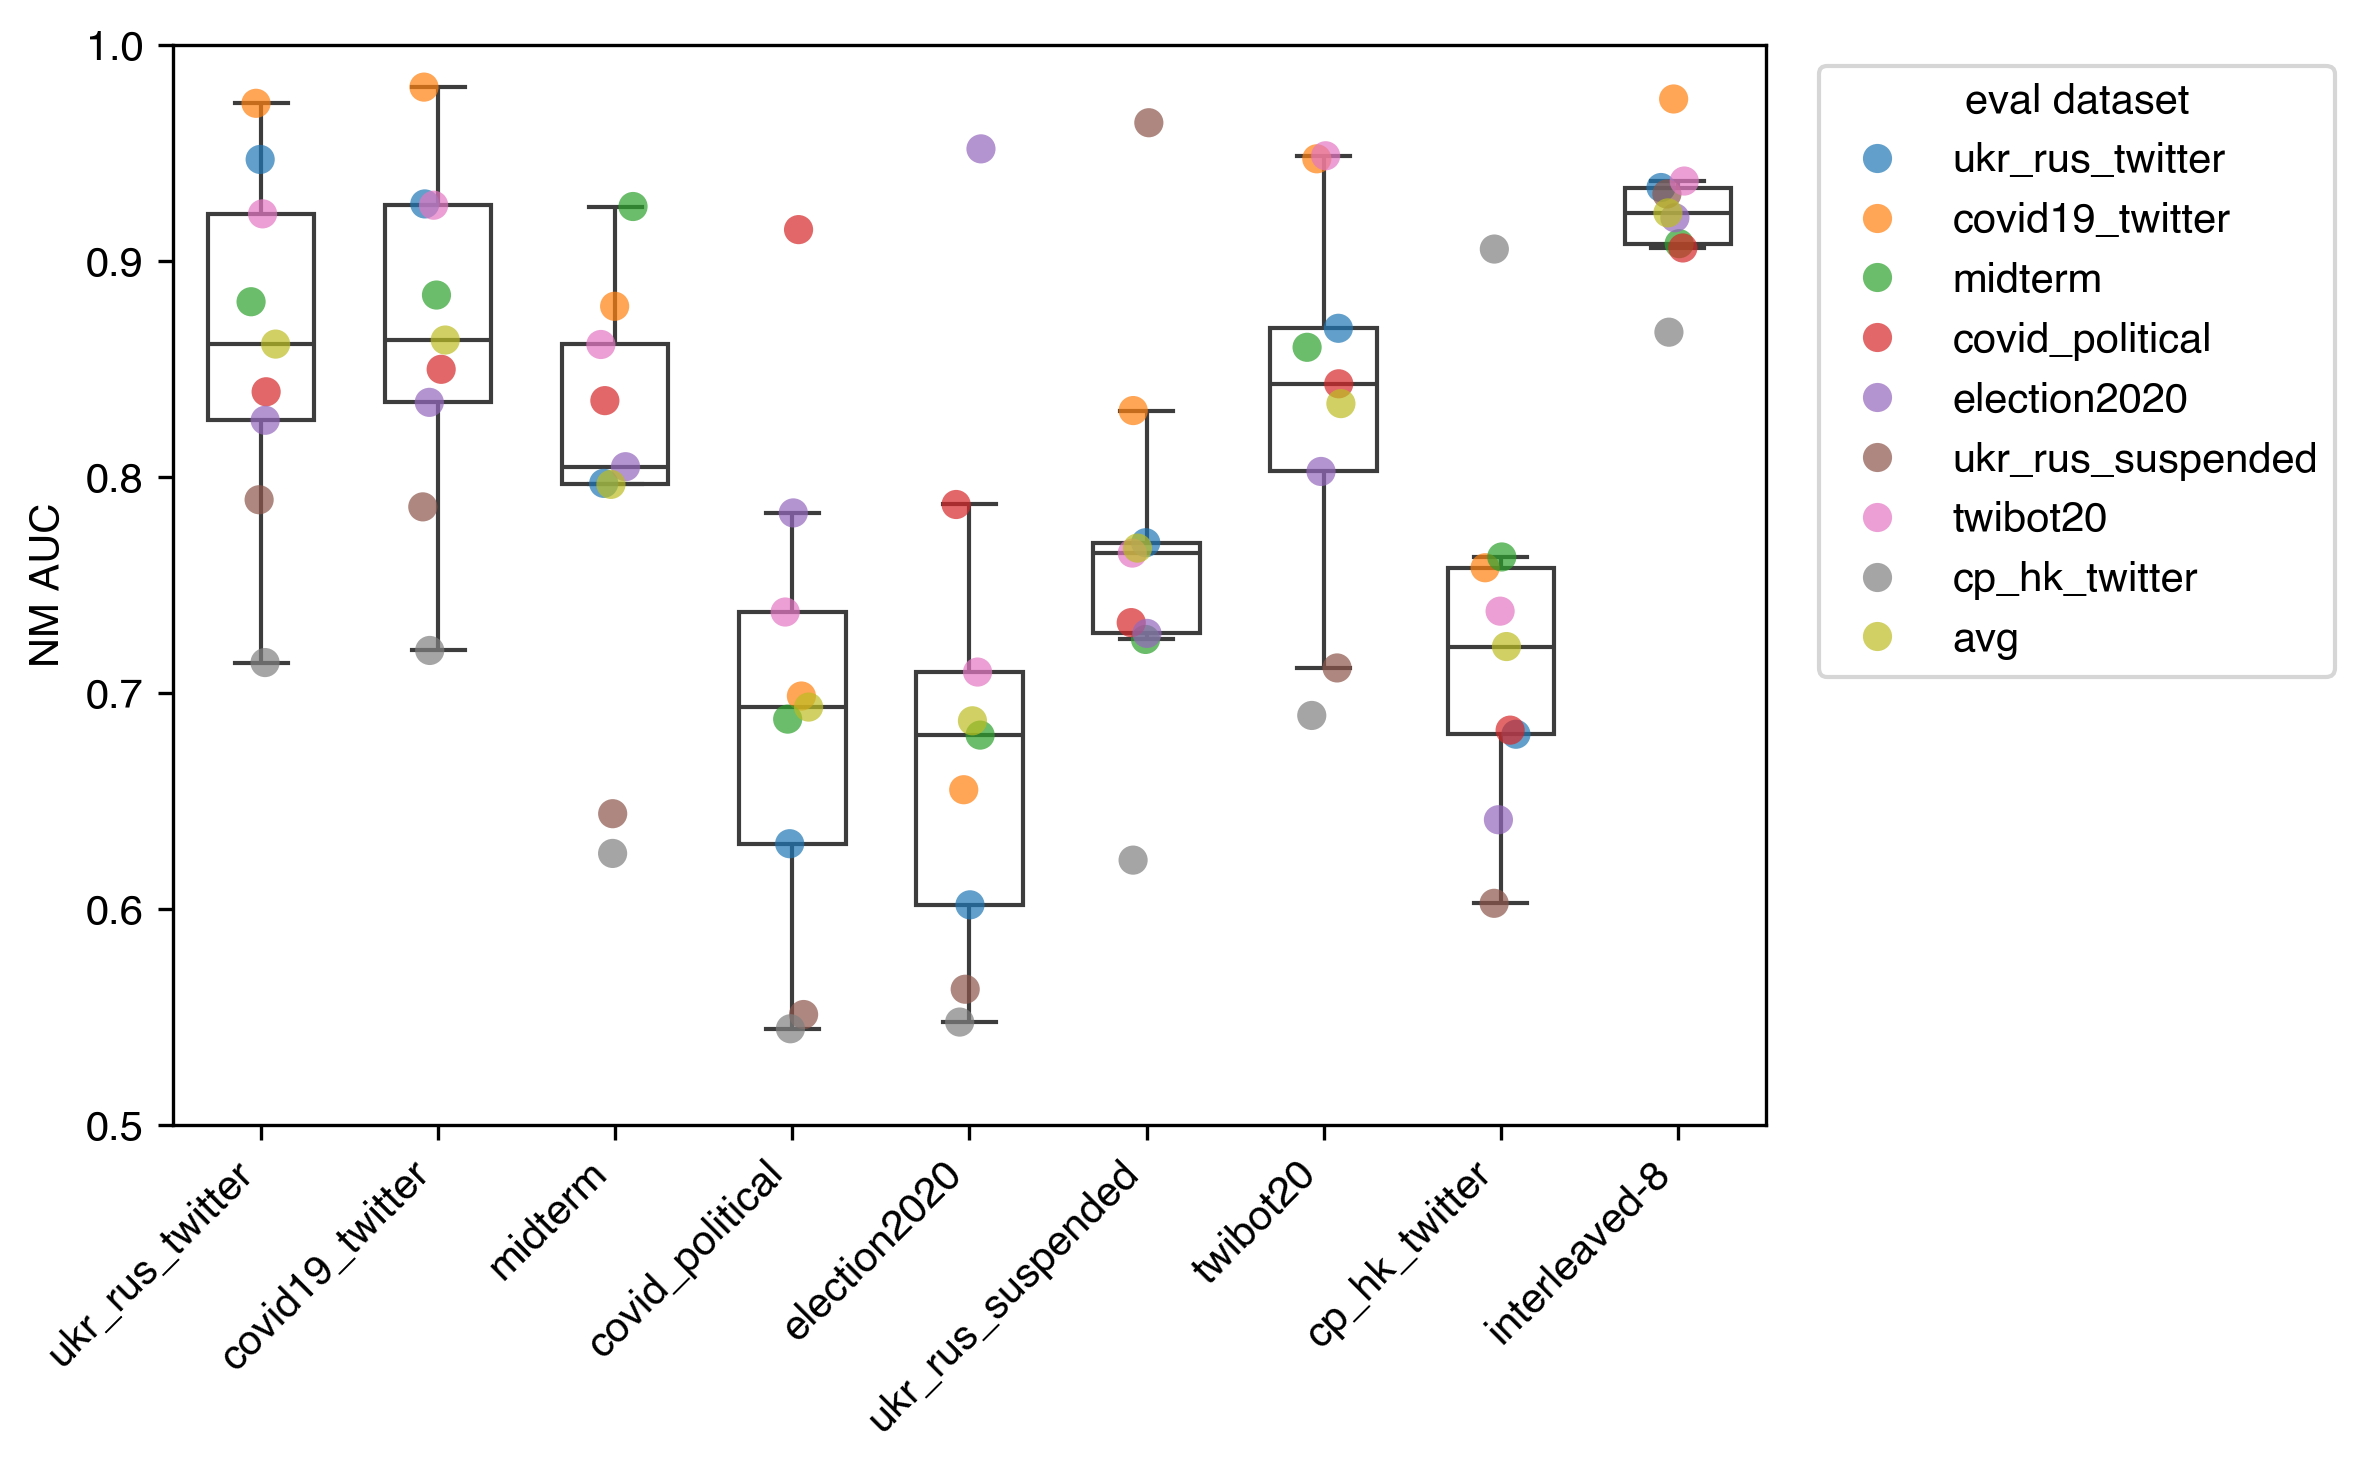

In [336]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5), dpi=300)

s = specialist_df.T.copy()
cmap = dict(zip(s.index, sns.color_palette('tab10', len(s.index))))

sns.boxplot(data=s, color='white', width=0.6, fliersize=0)

long_s = (s.rename_axis('eval dataset').reset_index()
            .melt(id_vars='eval dataset', var_name='train source', value_name='NM AUC'))
sns.stripplot(data=long_s, x='train source', y='NM AUC',
              hue='eval dataset', palette=cmap, size=7, alpha=0.7)

plt.ylabel('NM AUC')
plt.xlabel('')
plt.ylim(0.5, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='eval dataset', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

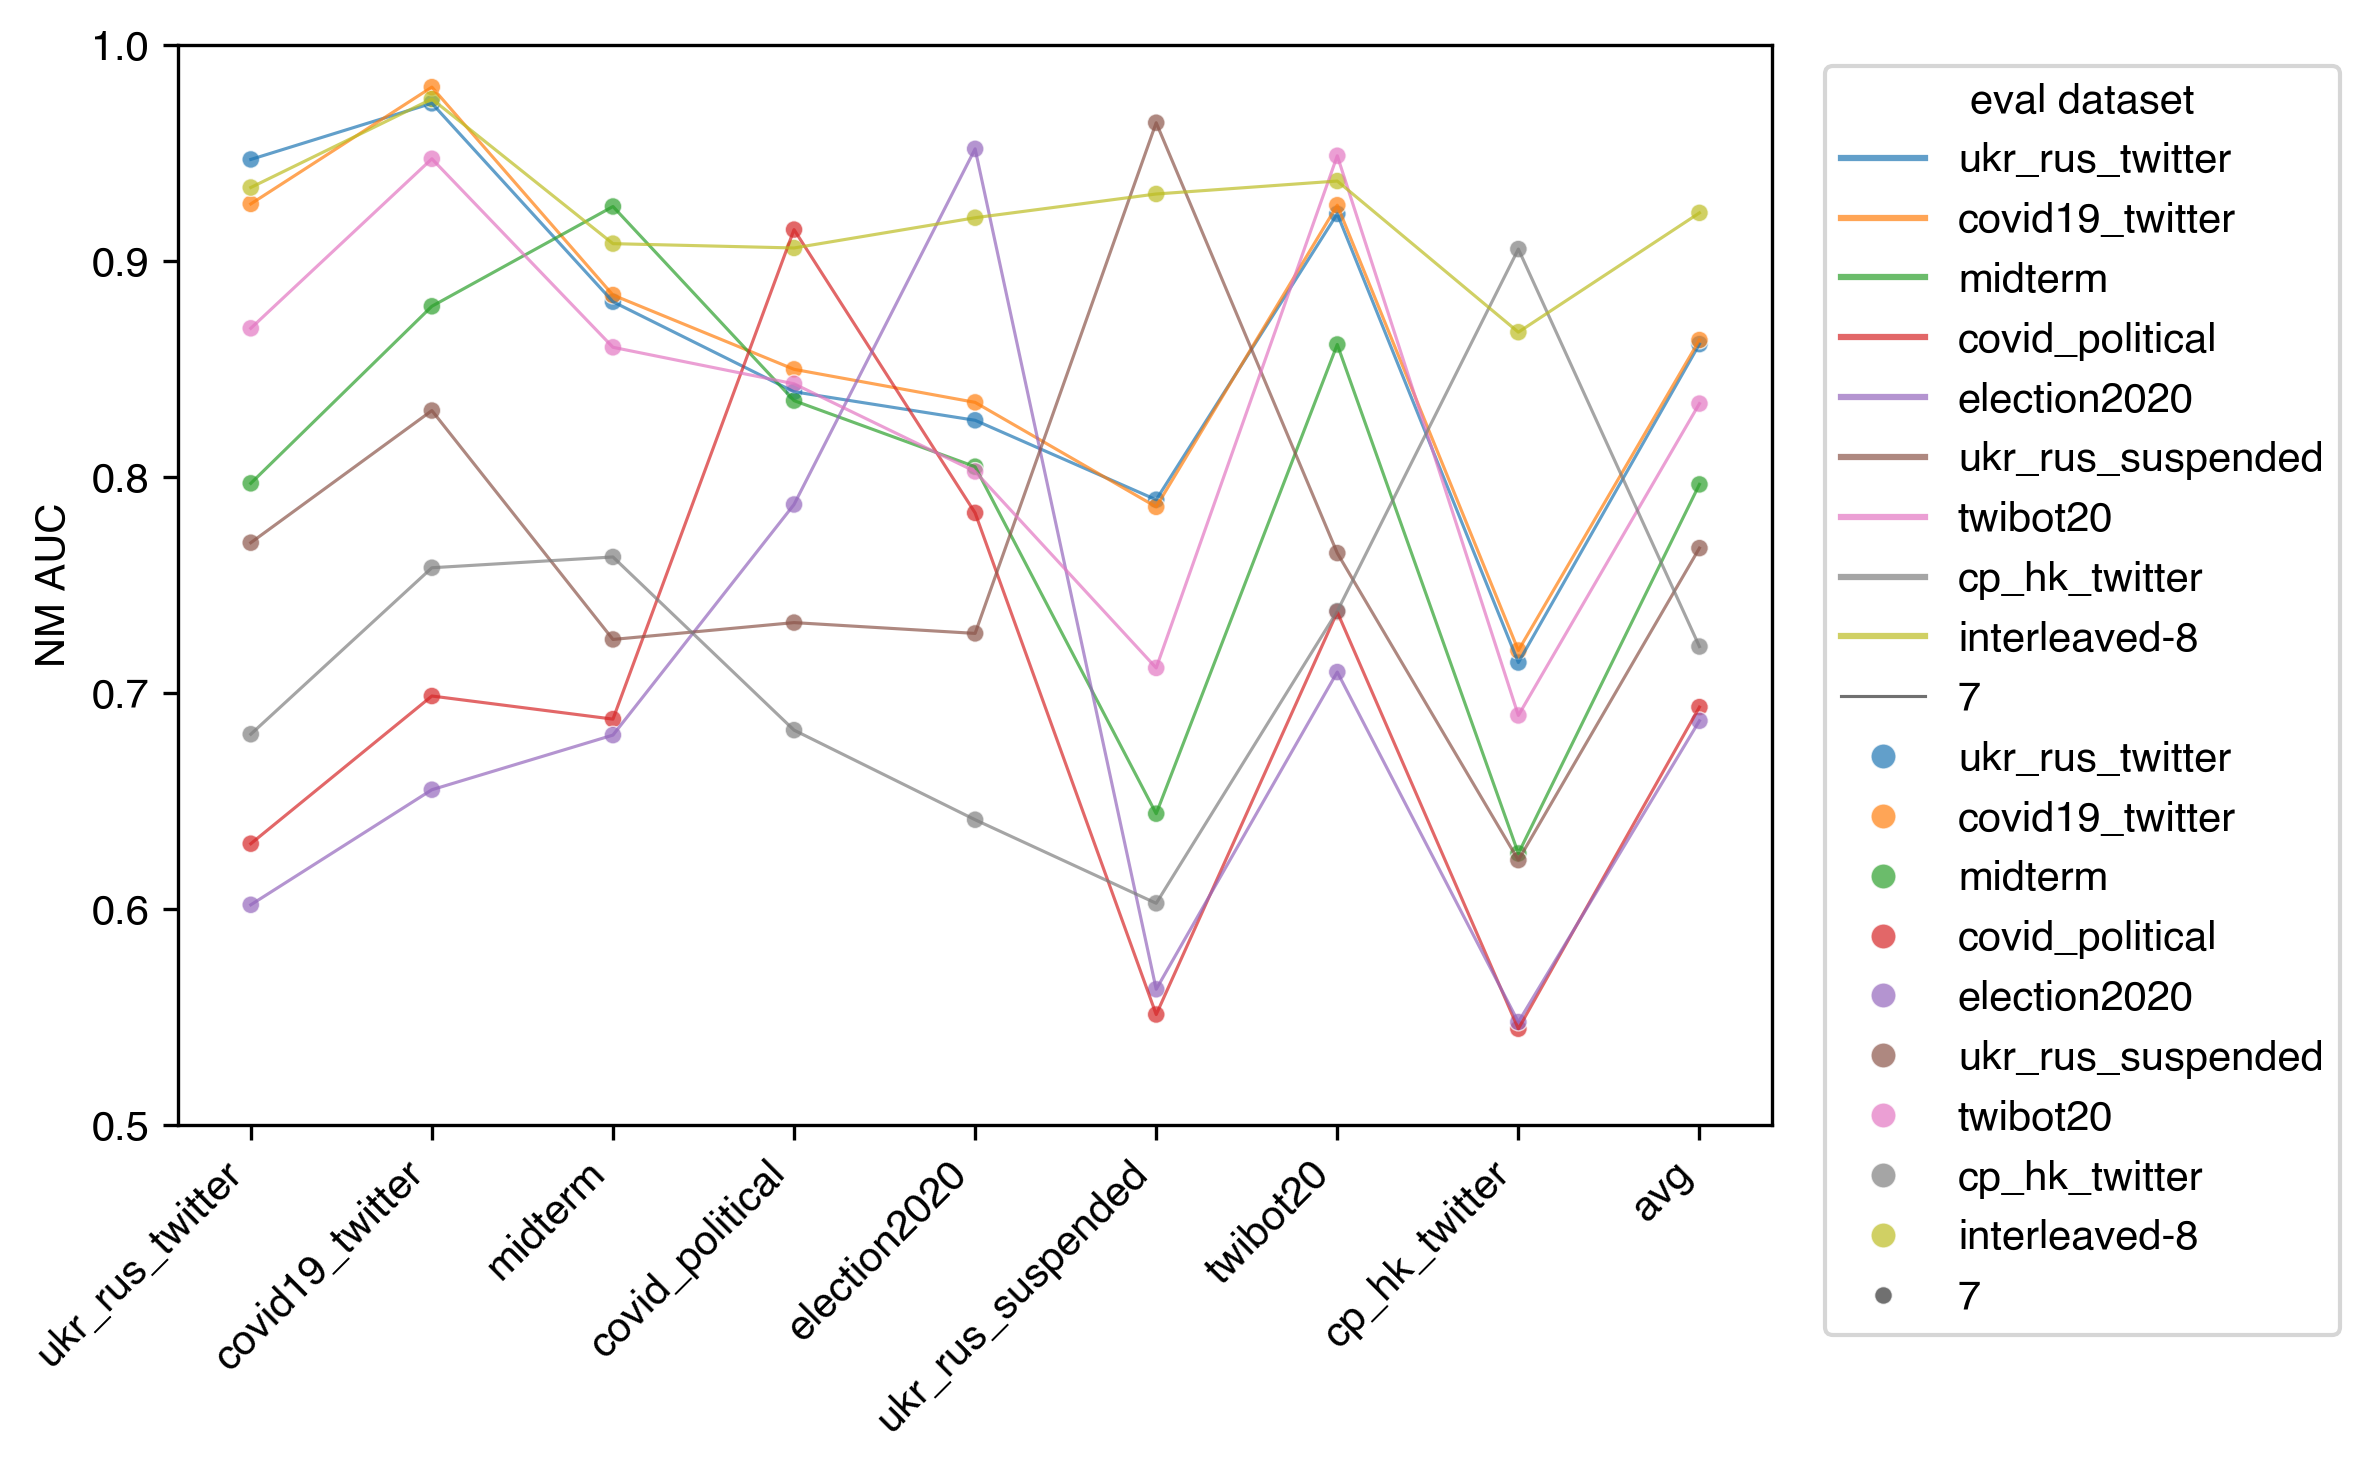

In [348]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5), dpi=300)

s = specialist_df.copy()
cmap = dict(zip(s.index, sns.color_palette('tab10', len(s.index))))

# sns.boxplot(data=s, color='white', width=0.6, fliersize=0)

long_s = (s.rename_axis('eval dataset').reset_index()
            .melt(id_vars='eval dataset', var_name='train source', value_name='NM AUC'))
sns.lineplot(data=long_s, x='train source', y='NM AUC', hue='eval dataset', palette=cmap, size=7, alpha=0.7)
sns.scatterplot(data=long_s, x='train source', y='NM AUC', hue='eval dataset', palette=cmap, size=7, alpha=0.7)

plt.ylabel('NM AUC')
plt.xlabel('')
plt.ylim(0.5, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='eval dataset', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [479]:
# deltas = specialist_df
s = specialist_df.iloc[:-1,:-1]
for i in zip((range(len(s))), (range(len(s)))):
    s.iloc[:,i[0]] /= s.iloc[i]
s

,ukr_rus_twitter,covid19_twitter,midterm,covid_political,election2020,ukr_rus_suspended,twibot20,cp_hk_twitter
train_graph,,,,,,,,
ukr_rus_twitter,1.000000,0.992351,0.952335,0.917879,0.867948,0.818880,0.971645,0.788515
covid19_twitter,0.978247,1.000000,0.955685,0.929251,0.876668,0.815456,0.975862,0.794699
midterm,0.841605,0.896481,1.000000,0.913395,0.845362,0.668050,0.907874,0.690889
covid_political,0.665364,0.712392,0.743407,1.000000,0.822881,0.571577,0.777274,0.601215
election2020,0.635480,0.668129,0.735409,0.860798,1.000000,0.583714,0.747971,0.604638
ukr_rus_suspended,0.812566,0.847221,0.783290,0.800984,0.764261,1.000000,0.806050,0.687465
twibot20,0.917423,0.966140,0.929529,0.921925,0.843051,0.738071,1.000000,0.761458
cp_hk_twitter,0.718902,0.772973,0.824578,0.746528,0.673600,0.625000,0.777696,1.000000


/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/2257430358.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  sp.loc['receiver_quality'] = sp.mean(0).values
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/2257430358.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  sp['donor_quality'] = sp.mean(1).values


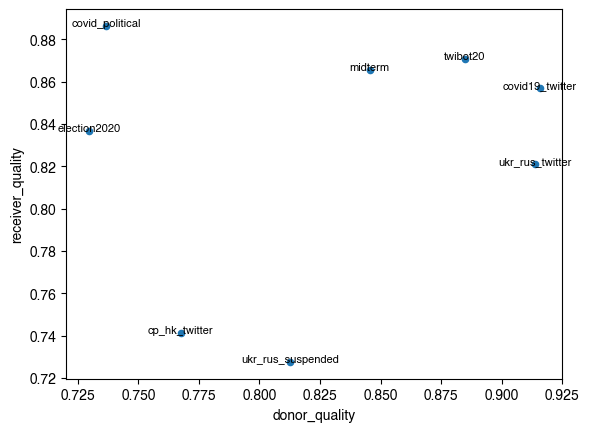

In [480]:
sp = s.copy()
sp.loc['receiver_quality'] = sp.mean(0).values
sp['donor_quality'] = sp.mean(1).values

sf = sp['donor_quality'][:-1].to_frame()
sf['receiver_quality'] = sp.T['receiver_quality'].T[:-1]

ax = sf.plot.scatter(x='donor_quality', y='receiver_quality')
for idx, row in sf.iterrows():
    ax.annotate(idx, (row['donor_quality'], row['receiver_quality']), 
                fontsize=8, ha='center')

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/2649541337.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  sp.loc['receiver_quality'] = sp.mean(0).values
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/2649541337.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  sp['donor_quality'] = sp.mean(1).values


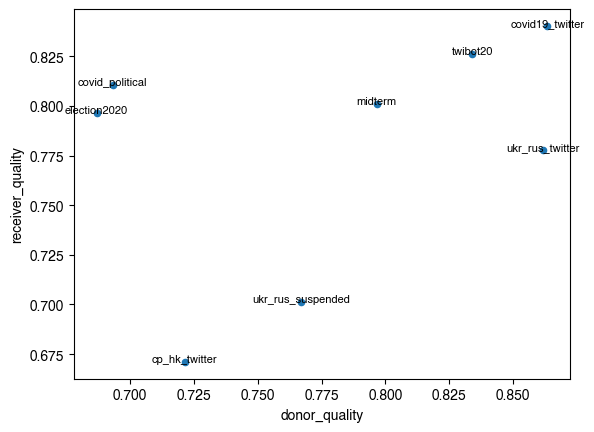

In [461]:
sp = specialist_df.iloc[:-1,:-1].copy()

sp.loc['receiver_quality'] = sp.mean(0).values
sp['donor_quality'] = sp.mean(1).values

sf = sp['donor_quality'][:-1].to_frame()
sf['receiver_quality'] = sp.T['receiver_quality'].T[:-1]

ax = sf.plot.scatter(x='donor_quality', y='receiver_quality')
for idx, row in sf.iterrows():
    ax.annotate(idx, (row['donor_quality'], row['receiver_quality']), 
                fontsize=8, ha='center')

In [547]:
a = df[df.order.eq('A')]
sdf = specialist_df[:-1].copy()
sdf = sdf[:-1].reset_index().rename(columns={'train_graph': 'sources'})
sdd = specialist_data.iloc[:1].copy()
sdd['sources'] = 'best'
a = pd.concat([a, sdf, sdd])

In [552]:
p = a.set_index('sources').iloc[:,7:]
divided = p / p.iloc[-1]
subtracted = p - p.iloc[-1]

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_74321/1459035193.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  divided.mean(1).sort_values().plot.bar()


(0.5, 1.0)

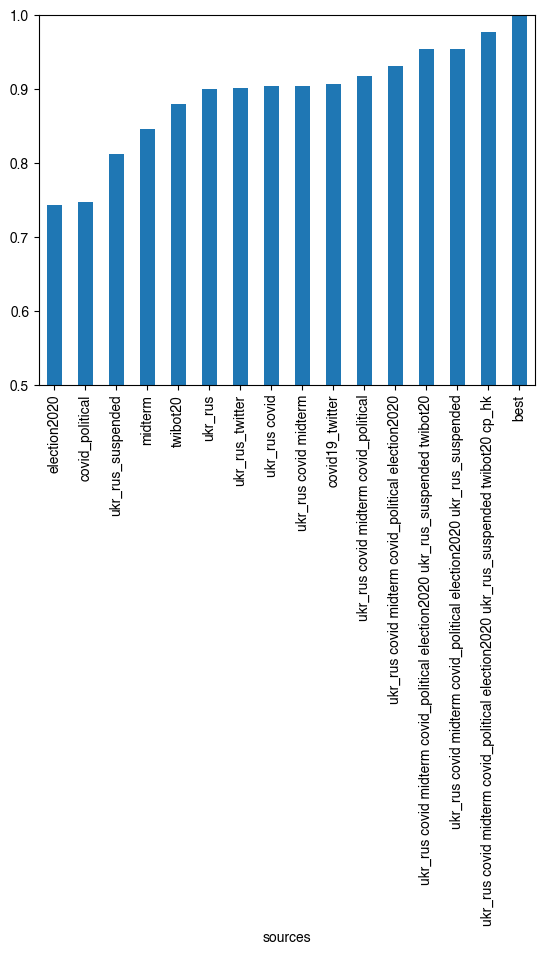

In [557]:
divided.mean(1).sort_values().plot.bar()
plt.ylim(0.5,1)